# **Machine Learning-Based Prediction of Wine Quality Using Physicochemical Properties**

# **Problem Statement**

Wine quality assessment traditionally relies on sensory evaluation performed by expert wine tasters. Although this approach provides valuable insights, it is subjective, time-consuming, resource-intensive, and may produce inconsistent results due to differences in human perception. As wine production continues to increase worldwide, wineries require objective and data-driven approaches that can support consistent quality assessment while reducing dependence on manual evaluation.

Machine learning offers an opportunity to model the complex relationships between measurable physicochemical properties and wine quality scores. By learning patterns from historical laboratory measurements, predictive models can estimate wine quality objectively and assist quality control laboratories in making faster and more consistent decisions.

The primary challenge addressed in this project is determining which machine learning regression algorithm provides the most accurate prediction of wine quality while identifying the physicochemical properties that contribute most significantly to those predictions. Developing an interpretable predictive framework can support production optimization, quality assurance, and evidence-based decision-making within the wine industry.

This study utilizes the publicly available **UCI Wine Quality Dataset**, containing physicochemical measurements of Portuguese Vinho Verde red wines. Multiple regression algorithms including **Linear Regression, Decision Tree Regression, Random Forest Regression, Gradient Boosting Regression, and Extreme Gradient Boosting (XGBoost)** will be developed, compared, and evaluated using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²)**. Model explainability techniques such as **SHAP (SHapley Additive exPlanations)** will be used to identify the most influential physicochemical properties contributing to wine quality predictions.

The findings of this study are expected to demonstrate how explainable machine learning can support objective wine quality assessment, improve production consistency, and provide actionable insights for data-driven quality management.

# **The Project Structure**

1. Problem Statement
2. Research Objectives
3. Research Questions
4. Dataset Description
5. Import Libraries
6. Load Dataset
7. Data Quality Assessment
8. Exploratory Data Analysis (EDA)
9. Data Preprocessing
10. Feature Engineering
11. Model Development
12. Model Evaluation
13. Hyperparameter Optimization
14. Model Comparison
15. Explainable AI (SHAP)
16. Business Insights & Recommendations
17. Conclusion

# **Research Objectives**

The primary objective of this study is to develop and compare multiple machine learning regression models for predicting wine quality using physicochemical properties obtained from the UCI Wine Quality Dataset.

The specific objectives are:

1. Identify the physicochemical properties that significantly influence wine quality.

2. Develop multiple machine learning regression models capable of predicting wine quality using physicochemical characteristics.

3. Compare the predictive performance of Linear Regression, Decision Tree Regression, Random Forest Regression, Gradient Boosting Regression, and XGBoost Regression.

4. Determine the best-performing regression model using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Coefficient of Determination (R²).

5. Interpret the contribution of individual physicochemical properties using explainable artificial intelligence (XAI) techniques such as SHAP.

6. Demonstrate how explainable machine learning can support objective wine quality assessment, production optimization, and data-driven decision-making within the wine industry.


# **Research Questions**

This study seeks to answer the following research questions:

**RQ1.** Which physicochemical properties significantly influence wine quality?

**RQ2.** How accurately can machine learning regression models predict wine quality using physicochemical properties?

**RQ3.** Which machine learning regression model provides the best predictive performance for wine quality prediction?

**RQ4.** Which physicochemical properties contribute the most to the predictive performance of the best-performing machine learning model?

# **Import Required Libraries**

The following libraries are imported to support data manipulation, visualization, exploratory data analysis, machine learning model development, model evaluation, hyperparameter optimization, and model explainability.

In [1]:
# ============================================================
# QM640 Data Analytics Capstone
# Import Required Libraries
# ============================================================

# -------------------------------
# General Libraries
# -------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# -------------------------------
# Visualization
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Figure settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8,5)

# -------------------------------
# Machine Learning
# -------------------------------
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold
)

from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -------------------------------
# Explainable AI
# -------------------------------
import shap

# -------------------------------
# Utility
# -------------------------------
import os

print("All libraries imported successfully.")

All libraries imported successfully.


# **Connect the Colab Environment to the GitHub Repository**

The project repository is cloned into the Google Colab runtime so that the notebook can access the raw dataset and later save processed files, figures, and outputs using the same project structure maintained in GitHub.

In [2]:
# ============================================================
# Clone the GitHub Repository into Google Colab
# ============================================================

import os

REPO_URL = "https://github.com/MBG0903/QM640-Wine-Quality-Capstone.git"
REPO_NAME = "QM640-Wine-Quality-Capstone"

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}
    print("Repository cloned successfully.")
else:
    print("Repository already exists in the Colab session.")

Repository already exists in the Colab session.


In [3]:
# ============================================================
# Set the Project Working Directory
# ============================================================

PROJECT_PATH = f"/content/{REPO_NAME}"
os.chdir(PROJECT_PATH)

print("Current working directory:")
print(os.getcwd())

Current working directory:
/content/QM640-Wine-Quality-Capstone


In [4]:
# ============================================================
# Load the Raw Wine Quality Dataset
# ============================================================

DATA_PATH = "data/raw/winequality-red.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (1599, 12)


# **Dataset Overview**

This section provides an initial overview of the Wine Quality dataset, including its dimensions, variables, data types, and sample observations. Understanding the dataset structure is an essential first step before assessing data quality and performing exploratory data analysis.

In [5]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nNumber of Records (Rows): {df.shape[0]}")
print(f"Number of Variables (Columns): {df.shape[1]}")

print("\nColumn Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

print("\nFirst Five Records:")
display(df.head())

DATASET OVERVIEW

Number of Records (Rows): 1599
Number of Variables (Columns): 12

Column Names:
 1. fixed acidity
 2. volatile acidity
 3. citric acid
 4. residual sugar
 5. chlorides
 6. free sulfur dioxide
 7. total sulfur dioxide
 8. density
 9. pH
10. sulphates
11. alcohol
12. quality

First Five Records:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
# ============================================================
# Dataset Structure
# ============================================================

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

df.info()

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
# ============================================================
# Dataset Summary Table
# ============================================================

summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Missing Values": df.isnull().sum().values
})

display(summary)

,Variable,Data Type,Non-Null Count,Missing Values
0,fixed acidity,float64,1599,0
1,volatile acidity,float64,1599,0
2,citric acid,float64,1599,0
3,residual sugar,float64,1599,0
4,chlorides,float64,1599,0
5,free sulfur dioxide,float64,1599,0
6,total sulfur dioxide,float64,1599,0
7,density,float64,1599,0
8,pH,float64,1599,0
9,sulphates,float64,1599,0


# **Data Quality Assessment**

Before developing machine learning models, it is essential to evaluate the quality of the dataset. This section examines missing values, duplicate records, and basic data integrity to ensure that the dataset is suitable for predictive modeling. Any issues identified during this assessment will be addressed before exploratory data analysis and model development.

In [8]:
# ============================================================
# Check Missing Values
# ============================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().mean()*100).round(2)
})

display(missing)

,Missing Values,Percentage (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [9]:
# ============================================================
# Check Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Number of duplicate records: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate records: 240
Percentage of duplicates: 15.01%


In [10]:
# ============================================================
# Investigate Duplicate Records
# ============================================================

duplicate_rows = df[df.duplicated(keep=False)]

print(f"Duplicate observations (including first occurrence): {duplicate_rows.shape[0]}")

display(duplicate_rows.head(20))

Duplicate observations (including first occurrence): 460


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
9,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
22,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
39,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
64,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5


In [11]:
# Number of unique duplicate groups

duplicate_groups = duplicate_rows.groupby(list(df.columns)).size().reset_index(name="Frequency")

duplicate_groups = duplicate_groups.sort_values(
    "Frequency",
    ascending=False
)

display(duplicate_groups.head(10))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Frequency
22,6.7,0.460,0.24,1.7,0.077,18.0,34.0,0.99480,3.39,0.60,10.6,6,4
81,7.5,0.510,0.02,1.7,0.084,13.0,31.0,0.99538,3.36,0.54,10.5,6,4
63,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,4
52,7.2,0.360,0.46,2.1,0.074,24.0,44.0,0.99534,3.40,0.85,11.0,7,4
40,7.0,0.690,0.07,2.5,0.091,15.0,21.0,0.99572,3.38,0.60,11.3,6,3
5,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,3
60,7.2,0.630,0.00,1.9,0.097,14.0,38.0,0.99675,3.37,0.58,9.0,6,3
39,7.0,0.650,0.02,2.1,0.066,8.0,25.0,0.99720,3.47,0.67,9.5,6,3
12,6.4,0.640,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.8,5,3
131,8.3,0.650,0.10,2.9,0.089,17.0,40.0,0.99803,3.29,0.55,9.5,5,3


### **Observations**

During data quality assessment, 240 duplicate observations (15.01% of the dataset) were identified. Examination confirmed that these records contained identical predictor values and identical target labels. Because duplicate observations do not contribute additional information and may bias model learning by disproportionately weighting repeated samples, they were removed prior to model development. The cleaned dataset contained 1,359 unique observations, which remained substantially larger than the minimum required sample size calculated using Cochran's formula.

In [12]:
# ============================================================
# Remove Duplicate Records
# ============================================================

df_clean = df.drop_duplicates().reset_index(drop=True)

print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", df_clean.shape)

print(f"Duplicate records removed: {df.shape[0] - df_clean.shape[0]}")

Original Dataset Shape : (1599, 12)
Cleaned Dataset Shape  : (1359, 12)
Duplicate records removed: 240


In [13]:
# ============================================================
# Save Cleaned Dataset
# ============================================================

import os

os.makedirs("data/processed", exist_ok=True)

output_path = "data/processed/winequality-red-clean.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Processed dataset saved successfully.")
print(f"Location: {output_path}")
print(f"Shape: {df_clean.shape}")

Processed dataset saved successfully.
Location: data/processed/winequality-red-clean.csv
Shape: (1359, 12)


In [14]:
# ============================================================
# Unique Values
# ============================================================

unique_values = pd.DataFrame({
    "Variable": df_clean.columns,
    "Unique Values": df.nunique().values
})

display(unique_values)

,Variable,Unique Values
0,fixed acidity,96
1,volatile acidity,143
2,citric acid,80
3,residual sugar,91
4,chlorides,153
5,free sulfur dioxide,60
6,total sulfur dioxide,144
7,density,436
8,pH,89
9,sulphates,96


In [15]:
# ============================================================
# Descriptive Statistics
# ============================================================

display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


# **2. Exploratory Data Analysis (EDA)**

## **2.1 - Target Variable Analysis**

The target variable (**quality**) represents the wine quality score assigned by expert tasters. Before developing predictive models, it is important to understand the distribution of the target variable, identify the most common quality levels, and assess whether class imbalance may influence model performance.

In [16]:
# ============================================================
# Distribution of Wine Quality Scores
# ============================================================

quality_distribution = (
    df_clean["quality"]
    .value_counts()
    .sort_index()
    .reset_index()
)

quality_distribution.columns = ["Quality Score", "Frequency"]
quality_distribution["Percentage (%)"] = (
    quality_distribution["Frequency"] /
    quality_distribution["Frequency"].sum() * 100
).round(2)

display(quality_distribution)

,Quality Score,Frequency,Percentage (%)
0,3,10,0.74
1,4,53,3.90
2,5,577,42.46
3,6,535,39.37
4,7,167,12.29
5,8,17,1.25


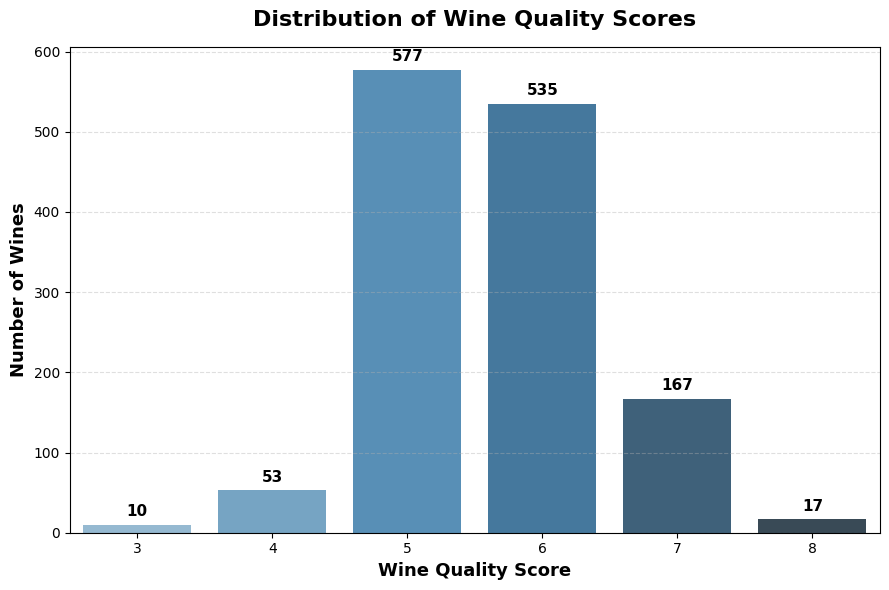

In [17]:
# ============================================================
# Distribution of Wine Quality Scores
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Count the quality scores
quality_counts = (
    df_clean["quality"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9,6))

ax = sns.barplot(
    x=quality_counts.index,
    y=quality_counts.values,
    palette="Blues_d"
)

# Add data labels
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0,4),
        textcoords='offset points'
    )

# Titles and labels
plt.title(
    "Distribution of Wine Quality Scores",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Wine Quality Score",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Number of Wines",
    fontsize=13,
    fontweight='bold'
)

# Gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# Summary Statistics of Target Variable
# ============================================================

display(df_clean["quality"].describe())

,quality
count,1359.000000
mean,5.623252
std,0.823578
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


### **Observations**

The cleaned dataset contains 1,359 unique wine samples, with quality scores ranging from 3 to 8. The average quality score is 5.62, while the median is 6, indicating that most wines are rated around the average quality level. The relatively low standard deviation (0.82) suggests limited variation in wine quality across the dataset. Furthermore, the interquartile range (5-6) indicates that the majority of wines are concentrated within a narrow quality band. This concentration is consistent with the distribution observed in the bar chart, where quality scores of 5 and 6 dominate the dataset. The relatively small number of observations with extreme quality scores (3, 4, 7, and 8) may make these quality levels more challenging for predictive models to estimate accurately. Consequently, model evaluation should consider not only overall prediction accuracy but also the model's ability to generalize across less frequently occurring quality scores.

## **2.2 - Univariate Analysis of Predictor Variables**

This section examines the distribution of each physicochemical property independently. Understanding the distribution, central tendency, variability, skewness, and kurtosis of predictor variables provides valuable insights into data characteristics and helps identify variables that may require transformation or special treatment before model development.

In [19]:
# ============================================================
# Skewness and Kurtosis Analysis
# ============================================================

distribution_summary = pd.DataFrame({
    "Mean": df_clean.mean(),
    "Median": df_clean.median(),
    "Standard Deviation": df_clean.std(),
    "Skewness": df_clean.skew(),
    "Kurtosis": df_clean.kurtosis()
})

display(distribution_summary.round(3))

,Mean,Median,Standard Deviation,Skewness,Kurtosis
fixed acidity,8.311,7.900,1.737,0.941,1.050
volatile acidity,0.529,0.520,0.183,0.729,1.249
citric acid,0.272,0.260,0.196,0.313,-0.789
residual sugar,2.523,2.200,1.352,4.548,29.365
chlorides,0.088,0.079,0.049,5.502,38.625
free sulfur dioxide,15.893,14.000,10.447,1.227,1.893
total sulfur dioxide,46.826,38.000,33.409,1.540,4.042
density,0.997,0.997,0.002,0.045,0.831
pH,3.310,3.310,0.155,0.232,0.880
sulphates,0.659,0.620,0.171,2.407,11.102


In [20]:
# ============================================================
# Distribution Classification
# ============================================================

def classify_kurtosis(x):

    if x < -1:
        return "Platykurtic"

    elif x <= 1:
        return "Mesokurtic"

    else:
        return "Leptokurtic"

distribution_summary["Kurtosis Type"] = (
    distribution_summary["Kurtosis"]
    .apply(classify_kurtosis)
)

display(distribution_summary.round(3))

,Mean,Median,Standard Deviation,Skewness,Kurtosis,Kurtosis Type
fixed acidity,8.311,7.900,1.737,0.941,1.050,Leptokurtic
volatile acidity,0.529,0.520,0.183,0.729,1.249,Leptokurtic
citric acid,0.272,0.260,0.196,0.313,-0.789,Mesokurtic
residual sugar,2.523,2.200,1.352,4.548,29.365,Leptokurtic
chlorides,0.088,0.079,0.049,5.502,38.625,Leptokurtic
free sulfur dioxide,15.893,14.000,10.447,1.227,1.893,Leptokurtic
total sulfur dioxide,46.826,38.000,33.409,1.540,4.042,Leptokurtic
density,0.997,0.997,0.002,0.045,0.831,Mesokurtic
pH,3.310,3.310,0.155,0.232,0.880,Mesokurtic
sulphates,0.659,0.620,0.171,2.407,11.102,Leptokurtic


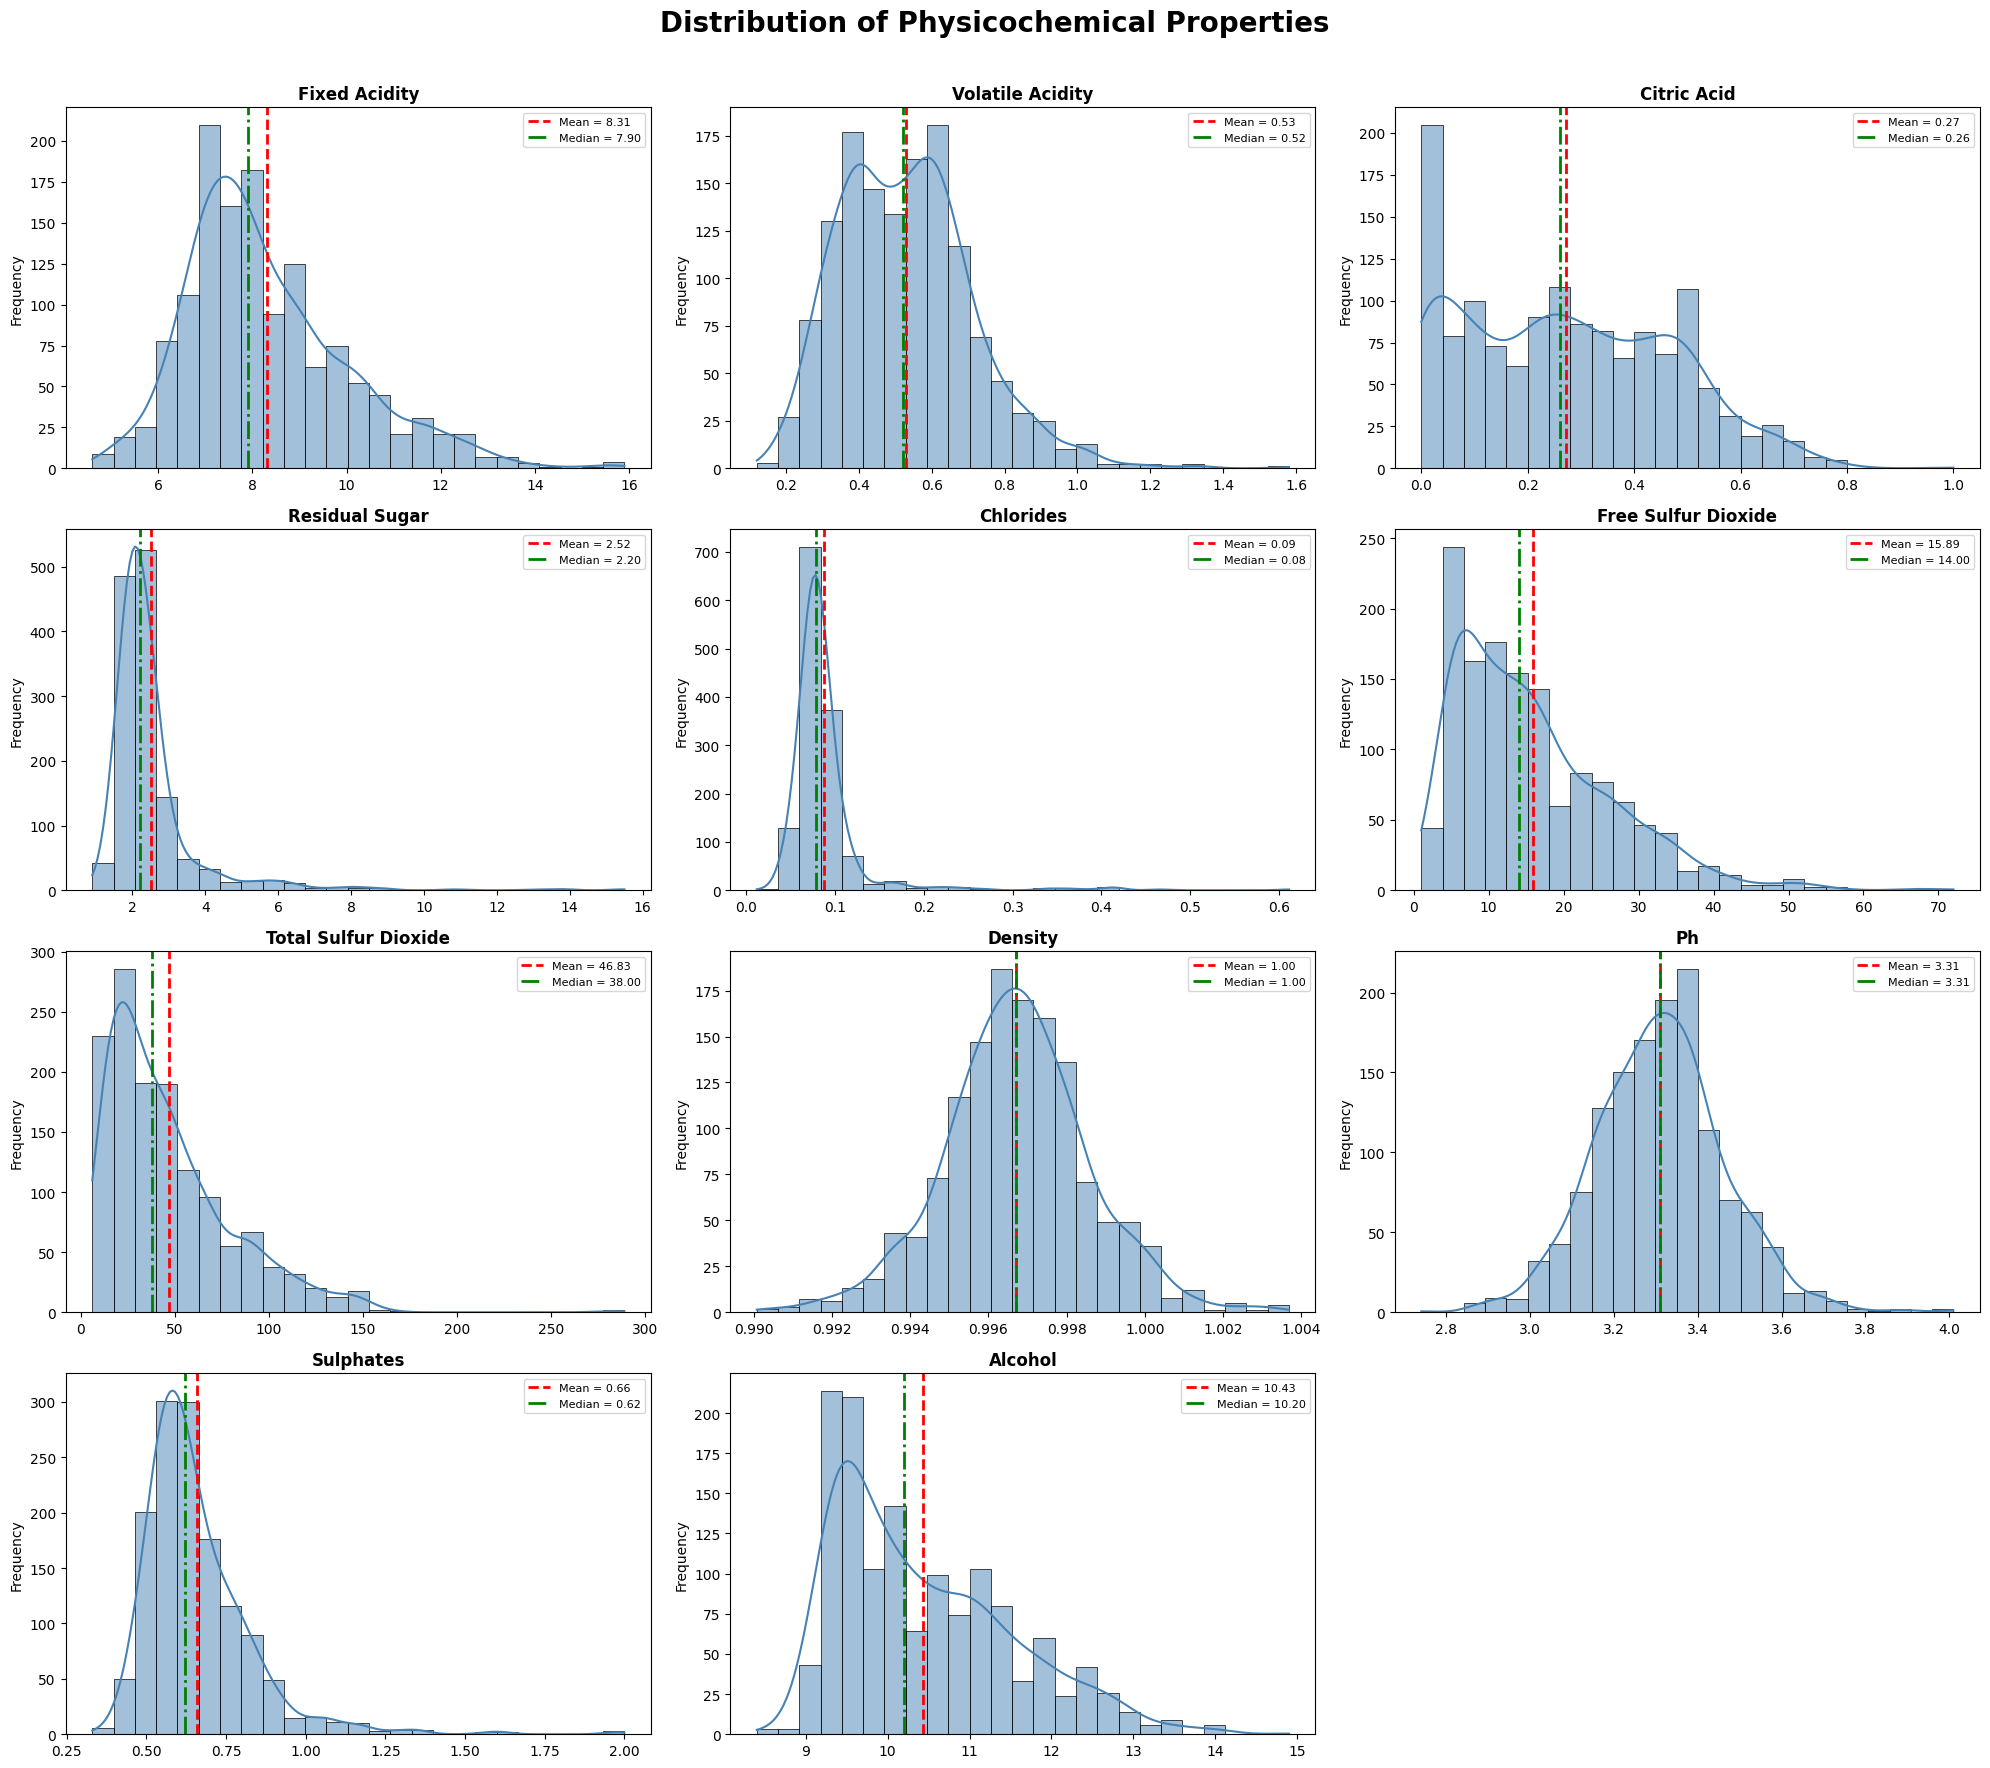

In [21]:
# ============================================================
# Publication Quality Histograms
# ============================================================

predictor_columns = df_clean.drop(columns="quality").columns

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(20,18)
)

axes = axes.flatten()

for i, column in enumerate(predictor_columns):

    ax = axes[i]

    sns.histplot(
        df_clean[column],
        bins=25,
        kde=True,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    mean = df_clean[column].mean()
    median = df_clean[column].median()

    ax.axvline(
        mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.2f}"
    )

    ax.axvline(
        median,
        color="green",
        linestyle="-.",
        linewidth=2,
        label=f"Median = {median:.2f}"
    )

    ax.set_title(
        column.title(),
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    ax.legend(fontsize=8)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Distribution of Physicochemical Properties",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.97])

plt.show()

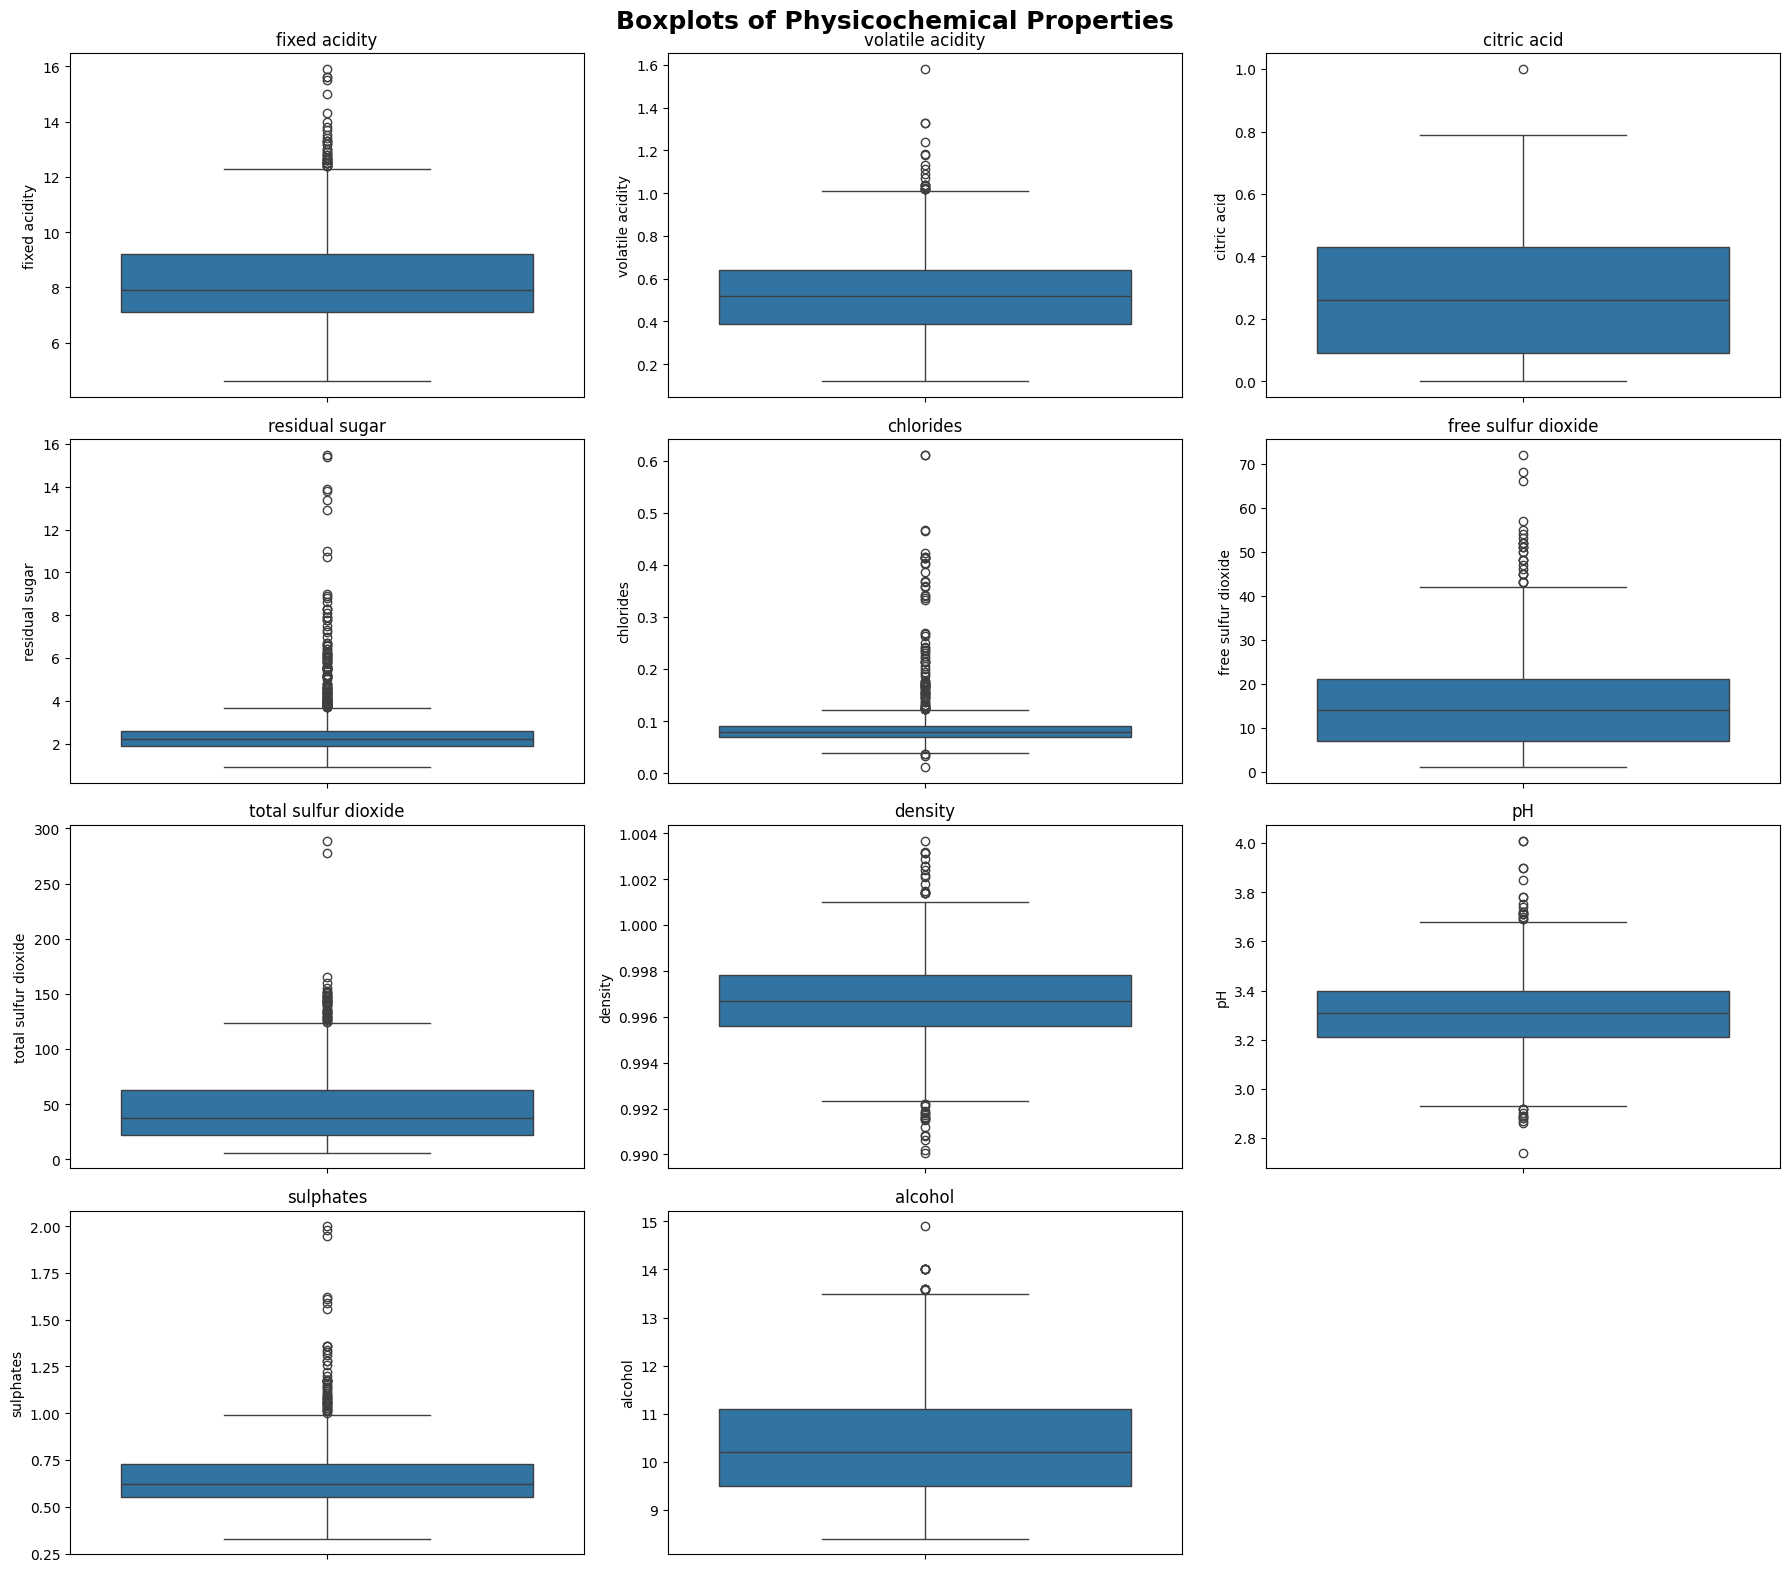

In [22]:
# ============================================================
# Boxplots of Predictor Variables
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(18,16))

axes = axes.flatten()

for i, column in enumerate(predictor_columns):

    sns.boxplot(
        y=df_clean[column],
        ax=axes[i]
    )

    axes[i].set_title(column)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Boxplots of Physicochemical Properties",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## **2.3 Correlation Analysis**

Correlation analysis is performed to examine the strength and direction of the linear relationships among the physicochemical properties and between each predictor variable and the target variable (**quality**). Understanding these relationships helps identify influential variables, detect multicollinearity, and support feature selection for predictive modeling.

In [23]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation_matrix = df_clean.corr(numeric_only=True)

display(correlation_matrix.round(2))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.26,0.67,0.11,0.09,-0.14,-0.10,0.67,-0.69,0.19,-0.06,0.12
volatile acidity,-0.26,1.00,-0.55,-0.00,0.06,-0.02,0.07,0.02,0.25,-0.26,-0.20,-0.40
citric acid,0.67,-0.55,1.00,0.14,0.21,-0.05,0.05,0.36,-0.55,0.33,0.11,0.23
residual sugar,0.11,-0.00,0.14,1.00,0.03,0.16,0.20,0.32,-0.08,-0.01,0.06,0.01
chlorides,0.09,0.06,0.21,0.03,1.00,0.00,0.05,0.19,-0.27,0.39,-0.22,-0.13
free sulfur dioxide,-0.14,-0.02,-0.05,0.16,0.00,1.00,0.67,-0.02,0.06,0.05,-0.08,-0.05
total sulfur dioxide,-0.10,0.07,0.05,0.20,0.05,0.67,1.00,0.08,-0.08,0.04,-0.22,-0.18
density,0.67,0.02,0.36,0.32,0.19,-0.02,0.08,1.00,-0.36,0.15,-0.50,-0.18
pH,-0.69,0.25,-0.55,-0.08,-0.27,0.06,-0.08,-0.36,1.00,-0.21,0.21,-0.06
sulphates,0.19,-0.26,0.33,-0.01,0.39,0.05,0.04,0.15,-0.21,1.00,0.09,0.25


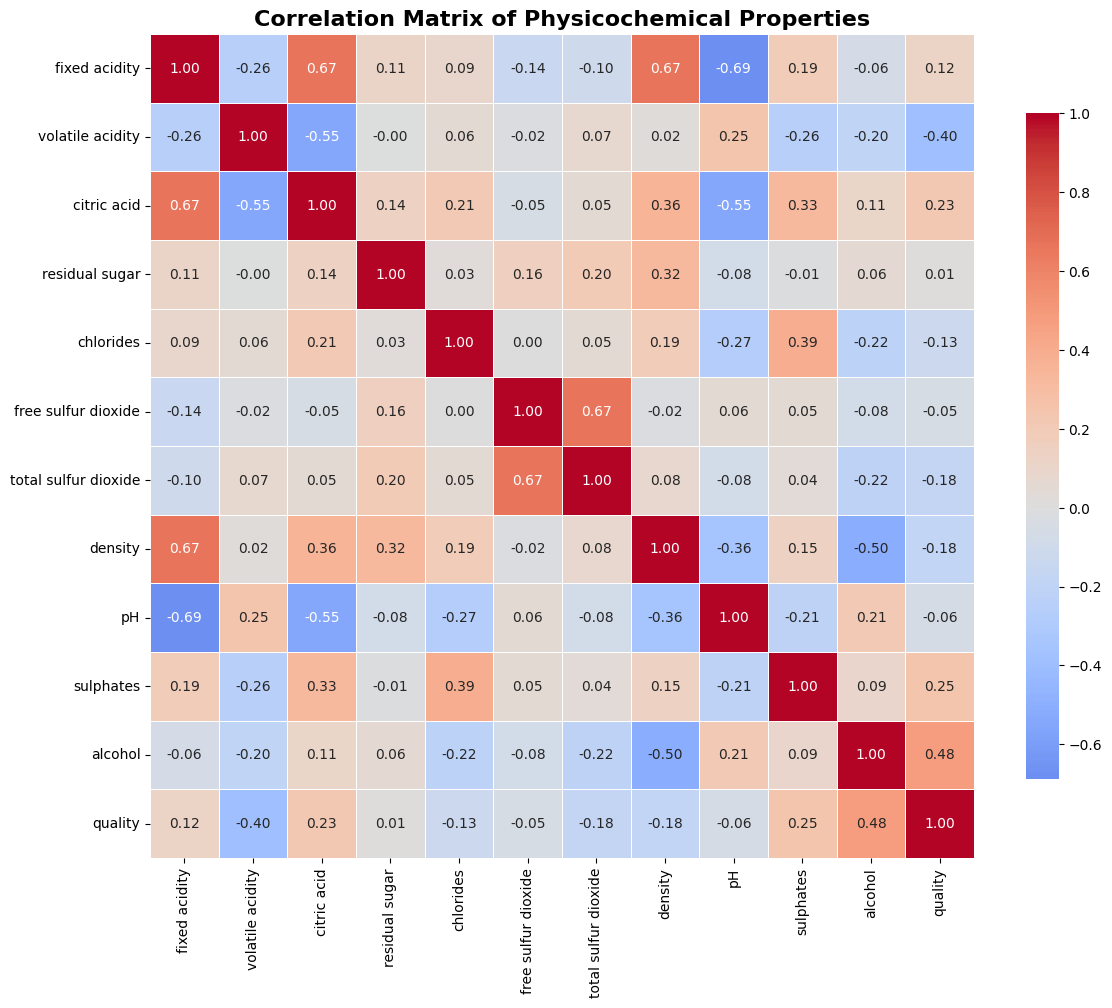

In [24]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlation Matrix of Physicochemical Properties",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [25]:
# ============================================================
# Correlation with Target Variable
# ============================================================

target_corr = (
    correlation_matrix["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

target_corr_df = target_corr.reset_index()
target_corr_df.columns = ["Feature", "Correlation with Quality"]

display(target_corr_df.round(3))

,Feature,Correlation with Quality
0,alcohol,0.480
1,sulphates,0.249
2,citric acid,0.228
3,fixed acidity,0.119
4,residual sugar,0.014
5,free sulfur dioxide,-0.050
6,pH,-0.055
7,chlorides,-0.131
8,total sulfur dioxide,-0.178
9,density,-0.184


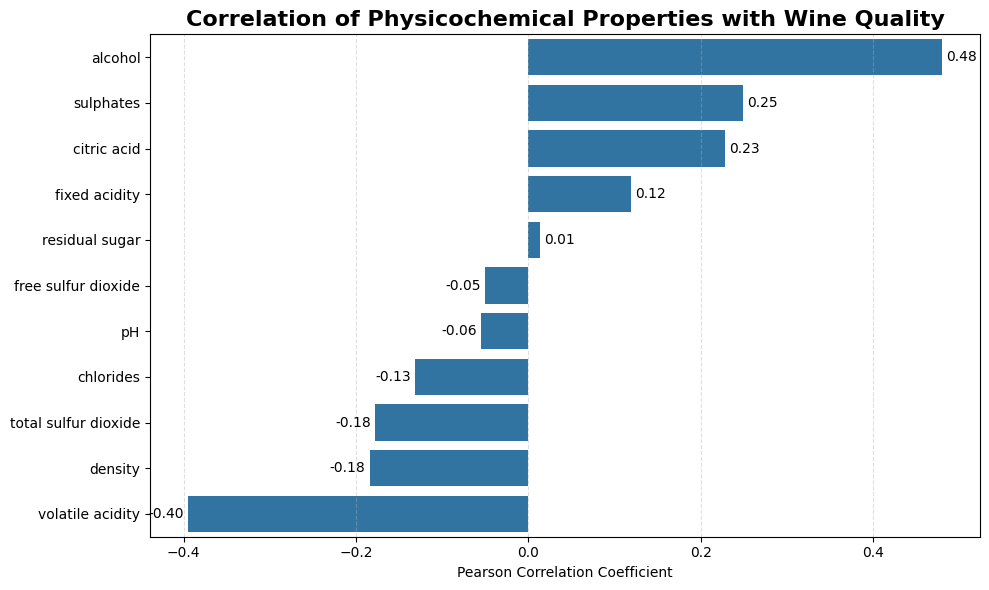

In [26]:
# ============================================================
# Correlation of Features with Wine Quality
# ============================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=target_corr_df,
    x="Correlation with Quality",
    y="Feature"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title(
    "Correlation of Physicochemical Properties with Wine Quality",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## **2.4 Bivariate Analysis**

Bivariate analysis examines the relationship between each predictor variable and the target variable (**quality**). Scatter plots with regression trend lines are used to visualize the direction and strength of these relationships, providing additional insight beyond the correlation coefficients calculated in the previous section.

In [27]:
# ============================================================
# Top Features by Absolute Correlation
# ============================================================

top_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)

print("Top correlated features:")
print(top_features.tolist())

Top correlated features:
['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'total sulfur dioxide']


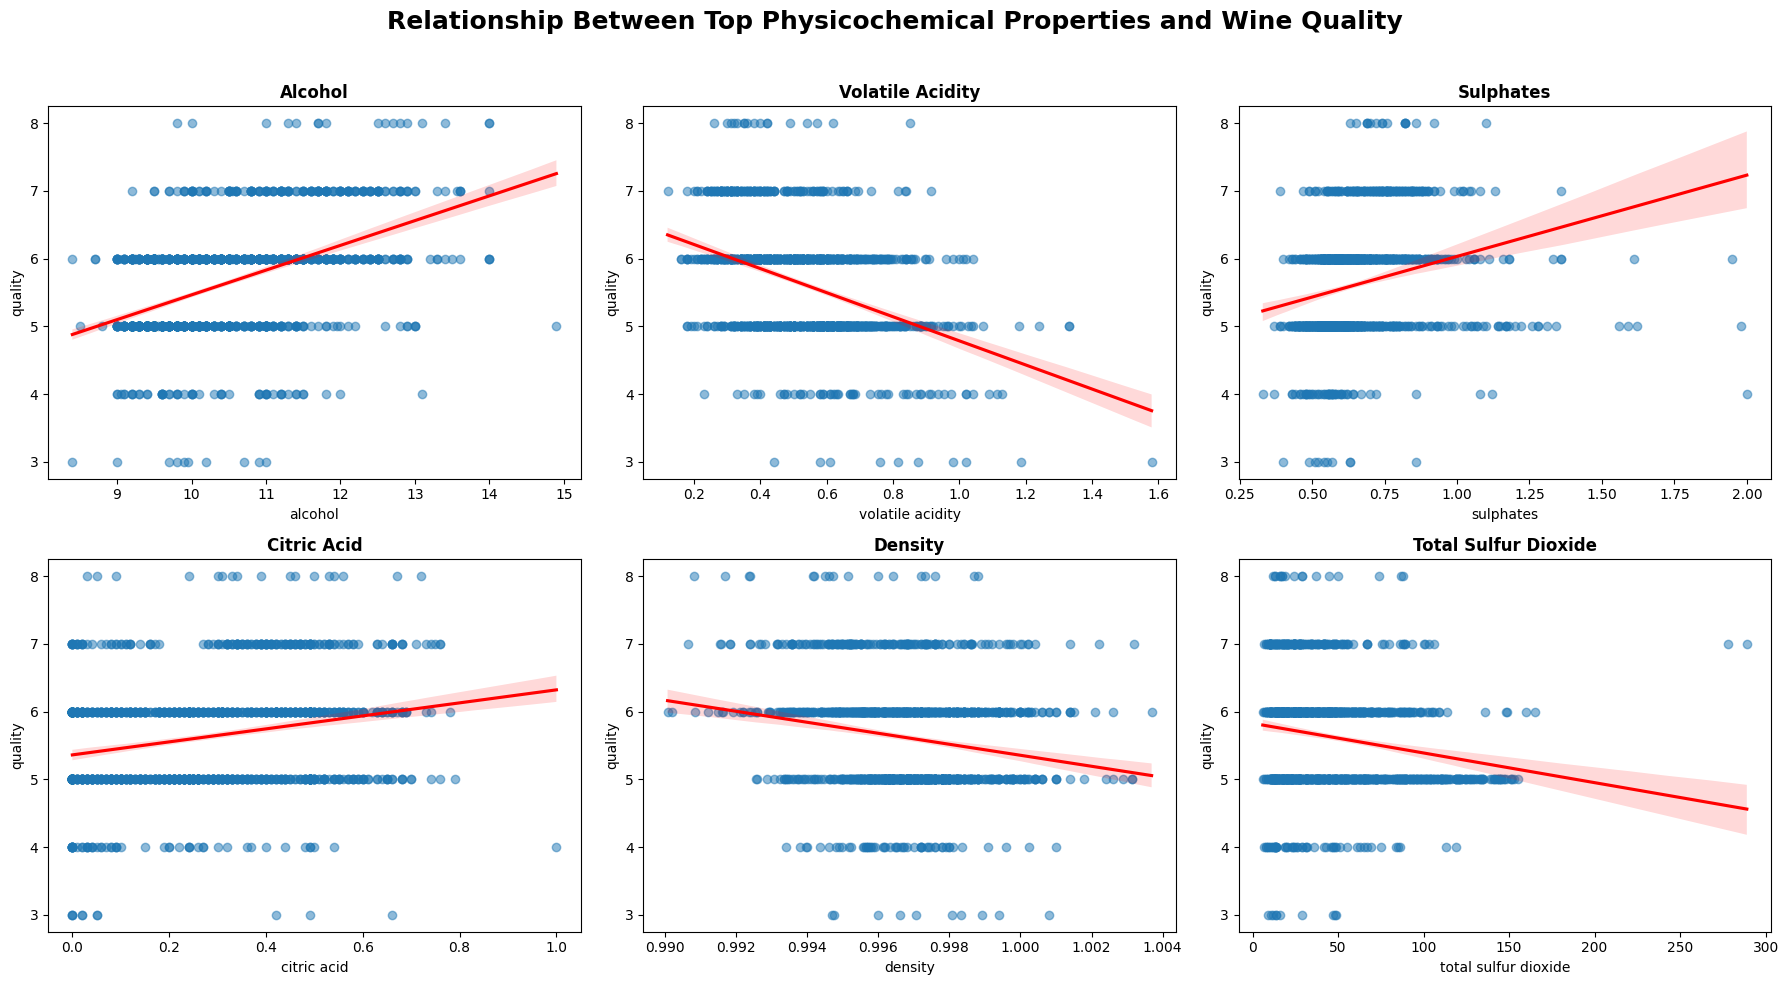

In [28]:
# ============================================================
# Scatter Plots of Top Predictors vs Wine Quality
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(top_features):

    sns.regplot(
        data=df_clean,
        x=feature,
        y="quality",
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"},
        ax=axes[i]
    )

    axes[i].set_title(feature.title(), fontsize=12, fontweight="bold")

plt.suptitle(
    "Relationship Between Top Physicochemical Properties and Wine Quality",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

## **2.5 Outlier Analysis**

Outlier analysis is performed to identify unusually high or low observations that may influence statistical analysis and machine learning model performance. The Interquartile Range (IQR) method is used to detect potential outliers for each predictor variable. The results are evaluated to determine whether outlier treatment is necessary prior to model development.

In [29]:
# ============================================================
# Outlier Detection using the IQR Method
# ============================================================

outlier_summary = []

predictors = df_clean.drop(columns="quality")

for column in predictors.columns:

    Q1 = predictors[column].quantile(0.25)
    Q3 = predictors[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = predictors[
        (predictors[column] < lower) |
        (predictors[column] > upper)
    ].shape[0]

    percentage = round(outliers / len(df_clean) * 100, 2)

    outlier_summary.append([
        column,
        Q1,
        Q3,
        IQR,
        outliers,
        percentage
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Outliers",
        "Percentage (%)"
    ]
)

display(
    outlier_summary.sort_values(
        "Percentage (%)",
        ascending=False
    )
)

,Variable,Q1,Q3,IQR,Outliers,Percentage (%)
3,residual sugar,1.9000,2.60000,0.70000,126,9.27
4,chlorides,0.0700,0.09100,0.02100,87,6.40
9,sulphates,0.5500,0.73000,0.18000,55,4.05
6,total sulfur dioxide,22.0000,63.00000,41.00000,45,3.31
0,fixed acidity,7.1000,9.20000,2.10000,41,3.02
7,density,0.9956,0.99782,0.00222,35,2.58
8,pH,3.2100,3.40000,0.19000,28,2.06
5,free sulfur dioxide,7.0000,21.00000,14.00000,26,1.91
1,volatile acidity,0.3900,0.64000,0.25000,19,1.40
10,alcohol,9.5000,11.10000,1.60000,12,0.88


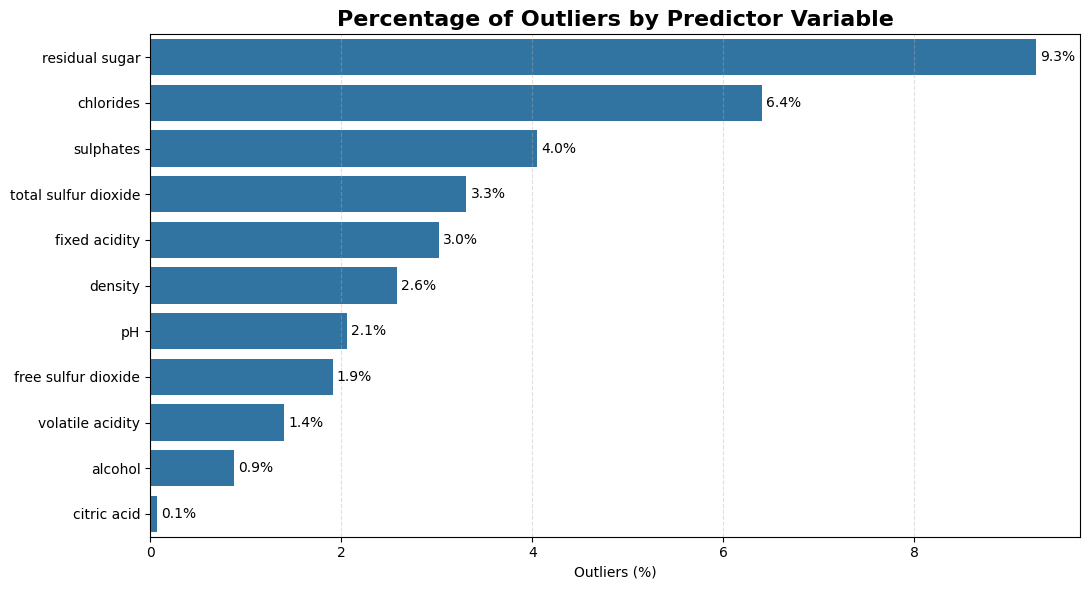

In [30]:
# ============================================================
# Percentage of Outliers by Variable
# ============================================================

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=outlier_summary.sort_values(
        "Percentage (%)",
        ascending=False
    ),
    x="Percentage (%)",
    y="Variable"
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title(
    "Percentage of Outliers by Predictor Variable",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Outliers (%)")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [31]:
# ============================================================
# Variables with Significant Outliers
# ============================================================

display(
    outlier_summary[
        outlier_summary["Percentage (%)"] > 5
    ].sort_values(
        "Percentage (%)",
        ascending=False
    )
)

,Variable,Q1,Q3,IQR,Outliers,Percentage (%)
3,residual sugar,1.90,2.600,0.700,126,9.27
4,chlorides,0.07,0.091,0.021,87,6.40


### **Decision Note on Outliers**

We recommend not removing or capping these outliers for the following reasons:

* The values are real physicochemical measurements from laboratory analyses, not apparent data-entry mistakes.

* Tree-based algorithms (Decision Tree, Random Forest, Gradient Boosting, and XGBoost) are generally robust to outliers.

* Removing valid observations could eliminate important variations associated with wine quality.

* Comparing Linear Regression with tree-based models will naturally reveal whether outliers have a meaningful impact on predictive performance.

* Any impact can be discussed later in the model evaluation section, making your methodology more transparent.

## **2.6 Multicollinearity Assessment**

Multicollinearity occurs when two or more predictor variables are highly correlated with one another. Excessive multicollinearity can reduce the stability and interpretability of regression models by inflating coefficient estimates. Therefore, the relationships among predictor variables are examined before model development.

In [32]:
# ============================================================
# Identify Highly Correlated Predictor Variables
# ============================================================

predictors = df_clean.drop(columns="quality")

corr_matrix = predictors.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper_triangle.stack()
    .reset_index()
)

high_corr.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr = high_corr[
    high_corr["Correlation"] >= 0.70
].sort_values(
    "Correlation",
    ascending=False
)

display(high_corr)

# ============================================================
# Multicollinearity Assessment
# ============================================================

if high_corr.empty:
    print("1. No predictor pairs have an absolute correlation of 0.70 or greater.")
    print("2. No strong multicollinearity was detected among the predictor variables.")
    print("3. All predictor variables will be retained for model development.")
else:
    print(f"Found {len(high_corr)} highly correlated predictor pair(s):")
    display(high_corr)

,Feature 1,Feature 2,Correlation


1. No predictor pairs have an absolute correlation of 0.70 or greater.
2. No strong multicollinearity was detected among the predictor variables.
3. All predictor variables will be retained for model development.


# **3 Model Evaluation Criteria**

# **3.1 - Model Evaluation Criteria**

The primary objective of this study is to develop and compare multiple machine learning regression models for predicting wine quality using physicochemical properties. To ensure a fair and comprehensive comparison, each model will be evaluated using a common set of regression performance metrics.

The selected evaluation metrics measure different aspects of prediction accuracy and together provide a balanced assessment of model performance.

### **Mean Absolute Error (MAE)**

Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted wine quality scores. MAE is easy to interpret because the error is expressed in the same units as the target variable. Lower MAE values indicate better predictive performance.

\[
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}|
\]

---

### **Root Mean Squared Error (RMSE)**

Root Mean Squared Error (RMSE) measures the square root of the average squared prediction errors. Since larger errors receive greater penalties, RMSE is particularly useful for identifying models that occasionally make large prediction errors.

\[
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2}
\]

---

### **Coefficient of Determination (R²)**

The coefficient of determination (R²) measures the proportion of variance in wine quality that can be explained by the predictor variables. R² values range from 0 to 1, where higher values indicate better explanatory power.

\[
R^2=1-\frac{\sum(y_i-\hat{y_i})^2}{\sum(y_i-\bar y)^2}
\]

---

### **Cross-Validation**

A 5-fold cross-validation strategy will be used during model development to evaluate the stability and generalization capability of each algorithm. Cross-validation helps reduce the likelihood of selecting a model that performs well only on a particular train-test split.

---

### **Model Selection Criteria**

The best-performing model will be selected based on the following criteria:

- Lowest Mean Absolute Error (MAE)
- Lowest Root Mean Squared Error (RMSE)
- Highest Coefficient of Determination (R²)
- Stable cross-validation performance across folds
- Model interpretability using SHAP feature importance

The selected evaluation framework ensures that the comparison considers both predictive accuracy and model robustness while supporting the research objectives of this study.

### **Quick Overview**

| Criterion                   | Why it is Used                                             | Desired Outcome       |
| --------------------------- | ---------------------------------------------------------- | --------------------- |
| **MAE**                     | Measures the average absolute prediction error             | Lower                 |
| **RMSE**                    | Penalizes larger prediction errors                         | Lower                 |
| **R²**                      | Measures the proportion of variance explained by the model | Higher                |
| **5-Fold Cross Validation** | Evaluates model stability and generalization               | Higher and consistent |
| **SHAP**                    | Explains feature contributions and model predictions       | High interpretability |


## **3.2 Data Preprocessing**

Before training the machine learning models, the cleaned dataset is prepared for analysis. Data preprocessing ensures that the predictor variables and target variable are correctly separated and that the data is partitioned into independent training and testing subsets.

To maintain the integrity of model evaluation, the dataset is divided into training (80%) and testing (20%) subsets using a fixed random state (**random_state = 42**) to ensure reproducibility. The training dataset will be used for model development, cross-validation, and hyperparameter optimization, while the testing dataset will be reserved exclusively for the final performance evaluation.

In [33]:
# ============================================================
# Separate Predictor Variables and Target Variable
# ============================================================

X = df_clean.drop(columns="quality")
y = df_clean["quality"]

print("=" * 60)
print("FEATURE MATRIX")
print("=" * 60)
print(f"Predictor Variables : {X.shape[1]}")
print(f"Observations        : {X.shape[0]}")

print("\nTarget Variable:")
print(y.name)

FEATURE MATRIX
Predictor Variables : 11
Observations        : 1359

Target Variable:
quality


In [34]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

TRAIN-TEST SPLIT
Training Samples : 1087
Testing Samples  : 272


In [35]:
# ============================================================
# Verify Dataset Dimensions
# ============================================================

split_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

display(split_summary)

,Dataset,Rows,Columns
0,Training Set,1087,11
1,Testing Set,272,11


In [36]:
# ============================================================
# Compare Target Variable Distribution
# ============================================================

distribution = pd.DataFrame({
    "Training Mean": [y_train.mean()],
    "Testing Mean": [y_test.mean()],
    "Training Std": [y_train.std()],
    "Testing Std": [y_test.std()]
})

display(distribution.round(3))

,Training Mean,Testing Mean,Training Std,Testing Std
0,5.626,5.614,0.825,0.821


## **3.3 Feature Scaling**

Machine learning algorithms differ in their sensitivity to the scale of predictor variables. Linear Regression assumes comparable feature scales and can benefit from standardization, whereas tree-based algorithms such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost are generally insensitive to feature scaling.

To support a fair comparison across models, standardized versions of the training and testing datasets are created using the StandardScaler. The scaler is fitted only on the training data and then applied to the testing data to prevent information leakage.

In [37]:
# ============================================================
# Feature Scaling using StandardScaler
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [38]:
# ============================================================
# Convert Scaled Arrays to DataFrames
# ============================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
649,-0.631638,-0.172462,-0.472778,-0.321789,-0.342364,-0.377365,-0.475851,0.471781,1.331499,0.377601,-0.769571
1071,-0.743460,0.258557,0.036144,1.683774,-0.048390,-0.377365,0.631470,-0.195113,0.071902,0.259621,0.507402
14,0.095209,-1.357767,1.461127,-0.544630,0.098596,1.790243,1.622230,0.101863,-0.054057,0.554571,0.051340
674,-0.687549,-0.064707,-1.236162,0.049611,-0.237373,0.470829,1.301690,0.388419,1.205539,-0.330279,-0.587147
684,-0.687549,0.420190,-1.287054,-0.024669,-0.132383,0.093854,1.155990,0.388419,1.079579,-0.330279,-0.678359


In [39]:
# ============================================================
# Verify Feature Scaling
# ============================================================

scaling_summary = pd.DataFrame({
    "Original Mean": X_train.mean(),
    "Scaled Mean": X_train_scaled.mean(),
    "Scaled Std Dev": X_train_scaled.std()
})

display(scaling_summary.round(3))

,Original Mean,Scaled Mean,Scaled Std Dev
fixed acidity,8.330,0.0,1.0
volatile acidity,0.532,0.0,1.0
citric acid,0.273,0.0,1.0
residual sugar,2.533,0.0,1.0
chlorides,0.087,0.0,1.0
free sulfur dioxide,16.004,0.0,1.0
total sulfur dioxide,47.330,-0.0,1.0
density,0.997,0.0,1.0
pH,3.309,-0.0,1.0
sulphates,0.656,0.0,1.0


## **3.4 Model Development Plan**

The following models will be developed and compared in this study. The table summarizes the model type, scaling requirements, planned hyperparameter optimization, and explainability approach.

| Model | Regression Type | Data Used | Hyperparameter Tuning | Explainability |
|---|---|---|---|---|
| Linear Regression | Linear model | Scaled features | Not required for the baseline model | Model coefficients |
| Decision Tree Regression | Tree-based model | Unscaled features | Yes | Feature importance |
| Random Forest Regression | Ensemble bagging model | Unscaled features | Yes | Feature importance and SHAP |
| Gradient Boosting Regression | Ensemble boosting model | Unscaled features | Yes | Feature importance and SHAP |
| XGBoost Regression | Gradient-boosted tree model | Unscaled features | Yes | Feature importance and SHAP |

## **3.5 Baseline Model: Linear Regression**

Linear Regression is used as the baseline model because it provides a simple and interpretable benchmark for predicting wine quality. The model estimates the linear relationship between the physicochemical predictor variables and the target variable (**quality**).

The standardized feature set is used so that the model coefficients can be compared on a common scale. Model performance will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

In [40]:
# ============================================================
# Unified Model Evaluation Function
# ============================================================

from sklearn.model_selection import KFold, cross_validate

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_model_with_cv(
    model_name,
    model,
    X_train_data,
    y_train_data,
    train_predictions,
    y_test_data,
    test_predictions
):
    """
    Evaluate a regression model using training performance,
    holdout test performance, and five-fold cross-validation.

    Returns
    -------
    pandas.DataFrame
        One-row summary of model performance.
    """

    # Training metrics
    train_mae = mean_absolute_error(
        y_train_data,
        train_predictions
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train_data,
            train_predictions
        )
    )

    train_r2 = r2_score(
        y_train_data,
        train_predictions
    )

    # Holdout test metrics
    test_mae = mean_absolute_error(
        y_test_data,
        test_predictions
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test_data,
            test_predictions
        )
    )

    test_r2 = r2_score(
        y_test_data,
        test_predictions
    )

    # Five-fold cross-validation on training data only
    scoring = {
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }

    cv_scores = cross_validate(
        model,
        X_train_data,
        y_train_data,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_mae = -cv_scores["test_MAE"].mean()
    cv_rmse = -cv_scores["test_RMSE"].mean()
    cv_r2 = cv_scores["test_R2"].mean()

    cv_mae_std = (-cv_scores["test_MAE"]).std()
    cv_rmse_std = (-cv_scores["test_RMSE"]).std()
    cv_r2_std = cv_scores["test_R2"].std()

    results = pd.DataFrame({
        "Model": [model_name],

        "Train MAE": [train_mae],
        "Train RMSE": [train_rmse],
        "Train R²": [train_r2],

        "Test MAE": [test_mae],
        "Test RMSE": [test_rmse],
        "Test R²": [test_r2],

        "CV MAE": [cv_mae],
        "CV MAE Std": [cv_mae_std],

        "CV RMSE": [cv_rmse],
        "CV RMSE Std": [cv_rmse_std],

        "CV R²": [cv_r2],
        "CV R² Std": [cv_r2_std]
    })

    return results

In [41]:
# ============================================================
# Train Baseline Linear Regression Model
# ============================================================

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [42]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_lr = linear_model.predict(X_train_scaled)
y_test_pred_lr = linear_model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [43]:
# ============================================================
# Initialize Model Results Storage
# ============================================================

all_model_results = []

print("Results container initialized.")

Results container initialized.


In [44]:
# ============================================================
# Evaluate Linear Regression Model
# ============================================================

lr_results = evaluate_model_with_cv(
    model_name="Linear Regression",
    model=linear_model,
    X_train_data=X_train_scaled,
    y_train_data=y_train,
    train_predictions=y_train_pred_lr,
    y_test_data=y_test,
    test_predictions=y_test_pred_lr
)

# Store results
all_model_results.append(lr_results)

# Display results
comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(
    comparison_table.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.51,0.6595,0.3599,0.5066,0.6523,0.3657,0.516,0.0251,0.6659,0.0452,0.341,0.0279


In [45]:
# ============================================================
# Linear Regression Coefficients
# ============================================================

lr_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

lr_coefficients["Absolute Coefficient"] = (
    lr_coefficients["Coefficient"].abs()
)

lr_coefficients = lr_coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(lr_coefficients.round(4))

,Feature,Coefficient,Absolute Coefficient
10,alcohol,0.3101,0.3101
1,volatile acidity,-0.1875,0.1875
9,sulphates,0.1478,0.1478
4,chlorides,-0.0929,0.0929
6,total sulfur dioxide,-0.0904,0.0904
8,pH,-0.0565,0.0565
5,free sulfur dioxide,0.0535,0.0535
0,fixed acidity,0.0218,0.0218
3,residual sugar,-0.0207,0.0207
7,density,-0.0152,0.0152


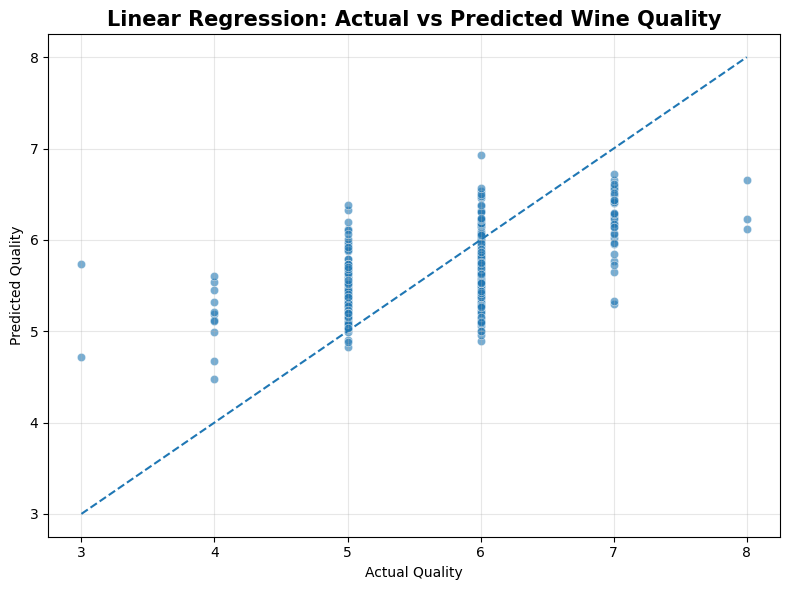

In [46]:
# ============================================================
# Actual vs Predicted Wine Quality
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_lr,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(
    "Linear Regression: Actual vs Predicted Wine Quality",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **3.6 Decision Tree Regression**

Decision Tree Regression is a non-parametric machine learning algorithm that partitions the feature space into a hierarchy of decision rules to predict the target variable. Unlike Linear Regression, Decision Trees can model nonlinear relationships and interactions among predictor variables without requiring feature scaling.

The Decision Tree model serves as the first nonlinear benchmark in this study and provides an interpretable comparison against the baseline Linear Regression model.

In [47]:
# ============================================================
# Train Decision Tree Regression
# ============================================================

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [48]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_dt = decision_tree.predict(X_train)
y_test_pred_dt = decision_tree.predict(X_test)

In [49]:
dt_results = evaluate_model_with_cv(
    model_name="Decision Tree",
    model=decision_tree,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_dt,
    y_test_data=y_test,
    test_predictions=y_test_pred_dt
)

all_model_results.append(dt_results)

comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(
    comparison_table.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.51,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree,0.00,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356


## **3.7 Random Forest Regression**

Random Forest Regression is an ensemble learning algorithm that constructs multiple decision trees using bootstrap sampling and random feature selection. The final prediction is obtained by averaging the predictions of all individual trees, which reduces variance and improves generalization compared to a single Decision Tree.

Unlike Linear Regression, Random Forest can model complex nonlinear relationships and interactions among predictor variables while remaining robust to outliers and multicollinearity. Because Random Forest is based on decision trees, feature scaling is not required.

In [50]:
# ============================================================
# Train Random Forest Regression
# ============================================================

random_forest = RandomForestRegressor(
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [51]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)

In [52]:
# ============================================================
# Evaluate Model Performance
# ============================================================

rf_results = evaluate_model_with_cv(
    model_name="Random Forest",
    model=random_forest,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_rf,
    y_test_data=y_test,
    test_predictions=y_test_pred_rf
)

all_model_results.append(rf_results)

comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(
    comparison_table.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522


In [53]:
# ============================================================
# Random Forest Feature Importance
# ============================================================

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

display(rf_importance.round(4))

,Feature,Importance
10,alcohol,0.2720
9,sulphates,0.1471
1,volatile acidity,0.1389
6,total sulfur dioxide,0.0705
4,chlorides,0.0619
8,pH,0.0576
3,residual sugar,0.0575
7,density,0.0518
5,free sulfur dioxide,0.0488
2,citric acid,0.0474


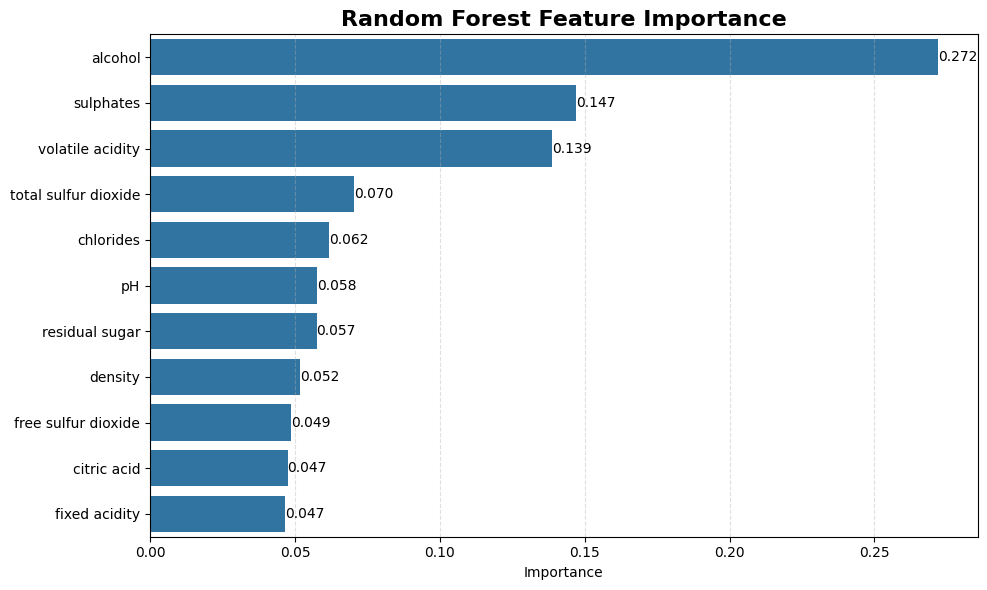

In [54]:
# ============================================================
# Feature Importance Plot
# ============================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## **3.8 Gradient Boosting Regression**

Gradient Boosting Regression is an ensemble learning algorithm that builds decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees, enabling the model to progressively improve its predictive performance.

Unlike Random Forest, which builds trees independently and averages their predictions, Gradient Boosting focuses on reducing residual errors at each iteration. This sequential learning process often results in higher predictive accuracy, particularly for structured tabular datasets such as the Wine Quality dataset.

Because Gradient Boosting is based on decision trees, feature scaling is not required.

In [55]:
# ============================================================
# Train Gradient Boosting Regression
# ============================================================

gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [56]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_gb = gradient_boosting.predict(X_train)
y_test_pred_gb = gradient_boosting.predict(X_test)

In [57]:
# ============================================================
# Evaluate Gradient Boosting Regression
# ============================================================

gb_results = evaluate_model_with_cv(
    model_name="Gradient Boosting",
    model=gradient_boosting,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_gb,
    y_test_data=y_test,
    test_predictions=y_test_pred_gb
)

all_model_results.append(gb_results)

comparison_table = pd.concat(
    all_model_results,
    ignore_index=True
)

display(comparison_table.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522
3,Gradient Boosting,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517


In [58]:
# ============================================================
# Gradient Boosting Feature Importance
# ============================================================

gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gradient_boosting.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
)

display(gb_importance.round(4))

,Feature,Importance
10,alcohol,0.3628
1,volatile acidity,0.1741
9,sulphates,0.1713
6,total sulfur dioxide,0.0670
8,pH,0.0475
7,density,0.0364
4,chlorides,0.0338
3,residual sugar,0.0314
0,fixed acidity,0.0297
2,citric acid,0.0269


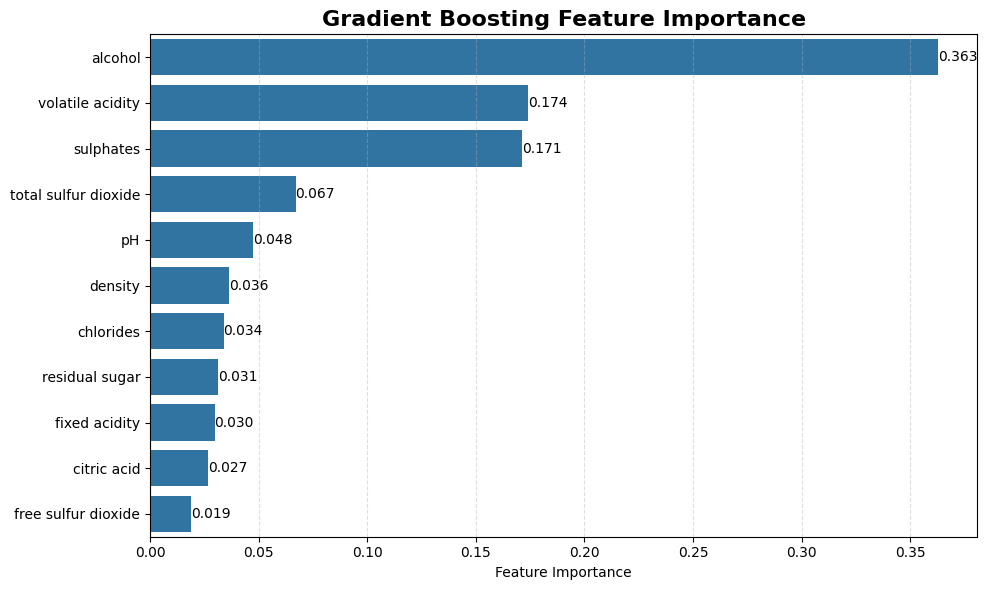

In [59]:
# ============================================================
# Gradient Boosting Feature Importance
# ============================================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=gb_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title(
    "Gradient Boosting Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## **3.9 XGBoost Regression**

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm that builds decision trees sequentially, with each tree attempting to correct errors made by the preceding trees.

XGBoost extends traditional gradient boosting through regularization, efficient tree construction, controlled learning rates, and additional mechanisms designed to reduce overfitting. These characteristics make it well suited for structured tabular datasets and nonlinear prediction problems.

Because XGBoost is based on decision trees, feature scaling is not required. The model is first evaluated using baseline settings before hyperparameter optimization is performed.

In [60]:
# ============================================================
# Train Baseline XGBoost Regression
# ============================================================

xgboost_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [61]:
# ============================================================
# Generate Predictions
# ============================================================

y_train_pred_xgb = xgboost_model.predict(X_train)
y_test_pred_xgb = xgboost_model.predict(X_test)

In [62]:
# ============================================================
# Evaluate XGBoost Regression
# ============================================================

xgb_results = evaluate_model_with_cv(
    model_name="XGBoost",
    model=xgboost_model,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_xgb,
    y_test_data=y_test,
    test_predictions=y_test_pred_xgb
)

all_model_results.append(xgb_results)

baseline_comparison = pd.concat(
    all_model_results,
    ignore_index=True
)

display(baseline_comparison.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522
3,Gradient Boosting,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517
4,XGBoost,0.0209,0.0305,0.9986,0.5006,0.6526,0.3652,0.5281,0.0205,0.6902,0.0300,0.2887,0.0546


In [63]:
# ============================================================
# XGBoost Feature Importance
# ============================================================

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgboost_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(xgb_importance.round(4))

,Feature,Importance
10,alcohol,0.3155
9,sulphates,0.1564
1,volatile acidity,0.1146
6,total sulfur dioxide,0.0709
8,pH,0.0639
7,density,0.0550
3,residual sugar,0.0522
4,chlorides,0.0520
5,free sulfur dioxide,0.0488
2,citric acid,0.0420


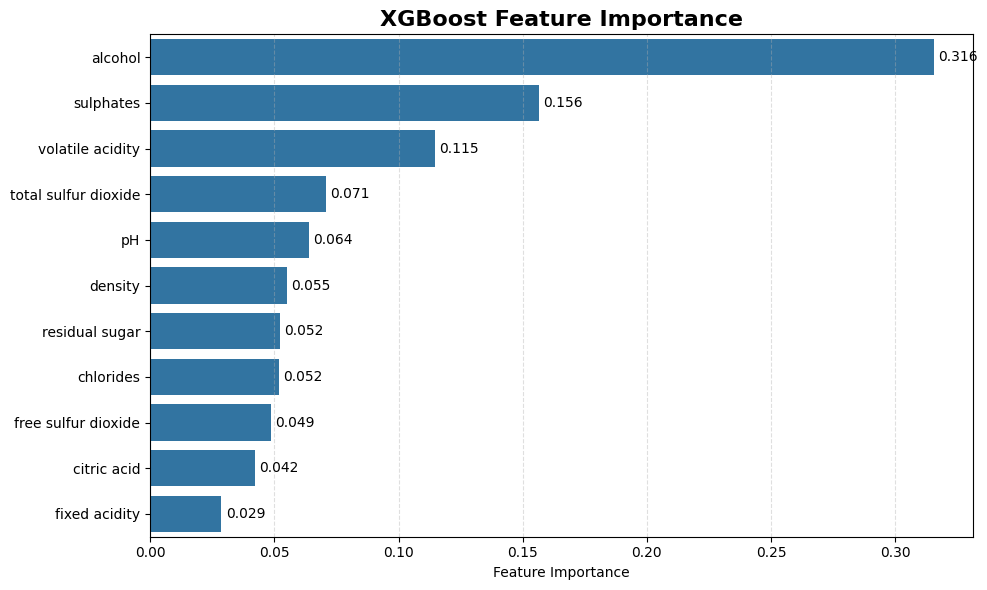

In [64]:
# ============================================================
# XGBoost Feature Importance Plot
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title(
    "XGBoost Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## **3.10 Hyperparameter Optimization**

The baseline models were developed using default hyperparameter settings. Hyperparameter optimization is now performed to identify configurations that improve predictive performance and reduce overfitting.

RandomizedSearchCV is used because it evaluates a defined number of randomly selected parameter combinations, making it more computationally efficient than an exhaustive grid search while still exploring a broad parameter space.

Optimization is performed exclusively on the training dataset using 5-fold cross-validation. The holdout test set remains excluded from model selection and is used only to evaluate the final tuned model. Cross-validated Root Mean Squared Error (RMSE) is used as the primary optimization criterion because it penalizes larger prediction errors more heavily.

In [65]:
# ============================================================
# Reusable Hyperparameter Optimization Function
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

def tune_regression_model(
    model_name,
    model,
    param_distributions,
    X_train_data,
    y_train_data,
    n_iter=30
):
    """
    Tune a regression model using RandomizedSearchCV.

    Parameters
    ----------
    model_name : str
        Descriptive name of the model.
    model : estimator
        Scikit-learn compatible regression estimator.
    param_distributions : dict
        Hyperparameter search space.
    X_train_data : pandas.DataFrame or numpy.ndarray
        Training predictor data.
    y_train_data : pandas.Series or numpy.ndarray
        Training target values.
    n_iter : int, default=30
        Number of parameter combinations to evaluate.

    Returns
    -------
    best_model : estimator
        Best fitted estimator identified by RandomizedSearchCV.
    tuning_summary : pandas.DataFrame
        Summary of the optimization results.
    search_object : RandomizedSearchCV
        Complete fitted search object for further inspection.
    """

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )

    search.fit(X_train_data, y_train_data)

    best_model = search.best_estimator_

    tuning_summary = pd.DataFrame({
        "Model": [model_name],
        "Best CV RMSE": [-search.best_score_],
        "Parameter Combinations Evaluated": [n_iter],
        "Best Parameters": [search.best_params_]
    })

    print(f"{model_name} optimization completed.")
    print(f"Best cross-validated RMSE: {-search.best_score_:.4f}")
    print("\nBest parameters:")

    for parameter, value in search.best_params_.items():
        print(f"  {parameter}: {value}")

    return best_model, tuning_summary, search

In [66]:
# ============================================================
# Initialize Tuned Model Results Storage
# ============================================================

tuned_model_results = []
tuning_summaries = []

print("Tuned-model result containers initialized.")

Tuned-model result containers initialized.


## **3.10.1 Decision Tree Hyperparameter Optimization**

The baseline Decision Tree demonstrated severe overfitting, achieving perfect performance on the training data but poor performance on both the holdout test set and cross-validation folds.

The model is therefore optimized by controlling tree complexity through parameters such as maximum depth, minimum samples required to split an internal node, minimum samples required at a leaf node, and the number of features considered during splitting.

In [67]:
# ============================================================
# Decision Tree Hyperparameter Search Space
# ============================================================

dt_param_distributions = {
    "max_depth": [None, 2, 3, 4, 5, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8, 10],
    "max_features": [None, "sqrt", "log2"],
    "criterion": [
        "squared_error",
        "friedman_mse",
        "absolute_error"
    ]
}

In [68]:
# ============================================================
# Optimize Decision Tree Regression
# ============================================================

tuned_decision_tree, dt_tuning_summary, dt_search = (
    tune_regression_model(
        model_name="Tuned Decision Tree",
        model=DecisionTreeRegressor(random_state=42),
        param_distributions=dt_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=40
    )
)

tuning_summaries.append(dt_tuning_summary)

Tuned Decision Tree optimization completed.
Best cross-validated RMSE: 0.6875

Best parameters:
  min_samples_split: 15
  min_samples_leaf: 8
  max_features: None
  max_depth: 4
  criterion: friedman_mse


In [69]:
# ============================================================
# Tuned Decision Tree Predictions
# ============================================================

y_train_pred_dt_tuned = tuned_decision_tree.predict(X_train)
y_test_pred_dt_tuned = tuned_decision_tree.predict(X_test)

In [70]:
# ============================================================
# Evaluate Tuned Decision Tree
# ============================================================

dt_tuned_results = evaluate_model_with_cv(
    model_name="Tuned Decision Tree",
    model=tuned_decision_tree,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_dt_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_dt_tuned
)

tuned_model_results.append(dt_tuned_results)

display(dt_tuned_results.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356


In [71]:
# ============================================================
# Baseline vs Tuned Decision Tree
# ============================================================

dt_before_after = pd.concat(
    [
        baseline_comparison[
            baseline_comparison["Model"] == "Decision Tree"
        ],
        dt_tuned_results
    ],
    ignore_index=True
)

display(dt_before_after.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Decision Tree,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
1,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356


## **3.10.2 Random Forest Hyperparameter Optimization**

The baseline Random Forest model performed better than both Linear Regression and the untuned Decision Tree, but the large difference between training and testing performance indicated that some overfitting remained.

Hyperparameter optimization is therefore performed to control model complexity, improve generalization, and identify a stronger combination of tree depth, number of estimators, feature selection strategy, and minimum sample requirements.

In [72]:
# ============================================================
# Random Forest Hyperparameter Search Space
# ============================================================

rf_param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 4, 6, 8, 10, 12, 15, 20],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [None, "sqrt", "log2", 0.5, 0.75],
    "bootstrap": [True, False]
}

In [73]:
# ============================================================
# Optimize Random Forest Regression
# ============================================================

tuned_random_forest, rf_tuning_summary, rf_search = (
    tune_regression_model(
        model_name="Tuned Random Forest",
        model=RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=rf_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=50
    )
)

tuning_summaries.append(rf_tuning_summary)

Tuned Random Forest optimization completed.
Best cross-validated RMSE: 0.6372

Best parameters:
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 8
  max_features: None
  max_depth: 10
  bootstrap: True


In [74]:
# ============================================================
# Tuned Random Forest Predictions
# ============================================================

y_train_pred_rf_tuned = tuned_random_forest.predict(X_train)
y_test_pred_rf_tuned = tuned_random_forest.predict(X_test)

In [75]:
# ============================================================
# Evaluate Tuned Random Forest
# ============================================================

rf_tuned_results = evaluate_model_with_cv(
    model_name="Tuned Random Forest",
    model=tuned_random_forest,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_rf_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_rf_tuned
)

tuned_model_results.append(rf_tuned_results)

display(rf_tuned_results.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526


In [76]:
# ============================================================
# Baseline vs Tuned Random Forest
# ============================================================

rf_before_after = pd.concat(
    [
        baseline_comparison[
            baseline_comparison["Model"] == "Random Forest"
        ],
        rf_tuned_results
    ],
    ignore_index=True
)

display(rf_before_after.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Random Forest,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522
1,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526


In [77]:
# ============================================================
# Best Random Forest Parameters
# ============================================================

print("Best Random Forest Parameters:\n")

for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

Best Random Forest Parameters:

n_estimators: 300
min_samples_split: 10
min_samples_leaf: 8
max_features: None
max_depth: 10
bootstrap: True


### **3.10.3 Gradient Boosting Hyperparameter Optimization**

The baseline Gradient Boosting model demonstrated strong predictive performance compared with the previous models. Hyperparameter optimization is performed to further improve model generalization by identifying an appropriate combination of the learning rate, number of boosting stages, tree depth, and minimum sample requirements.

RandomizedSearchCV with 5-fold cross-validation is employed to efficiently search the parameter space while reducing computational cost.

In [78]:
# ============================================================
# Gradient Boosting Hyperparameter Search Space
# ============================================================

gb_param_distributions = {

    "n_estimators": [100, 150, 200, 300, 400],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "min_samples_split": [
        2,
        5,
        10,
        15
    ],

    "min_samples_leaf": [
        1,
        2,
        4,
        6
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

In [79]:
# ============================================================
# Optimize Gradient Boosting Regression
# ============================================================

tuned_gradient_boosting, gb_tuning_summary, gb_search = (

    tune_regression_model(

        model_name="Tuned Gradient Boosting",

        model=GradientBoostingRegressor(
            random_state=42
        ),

        param_distributions=gb_param_distributions,

        X_train_data=X_train,

        y_train_data=y_train,

        n_iter=50

    )

)

tuning_summaries.append(gb_tuning_summary)

Tuned Gradient Boosting optimization completed.
Best cross-validated RMSE: 0.6424

Best parameters:
  subsample: 1.0
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_depth: 5
  learning_rate: 0.01


In [80]:
# ============================================================
# Tuned Gradient Boosting Predictions
# ============================================================

y_train_pred_gb_tuned = tuned_gradient_boosting.predict(X_train)

y_test_pred_gb_tuned = tuned_gradient_boosting.predict(X_test)

In [81]:
# ============================================================
# Evaluate Tuned Gradient Boosting
# ============================================================

gb_tuned_results = evaluate_model_with_cv(

    model_name="Tuned Gradient Boosting",

    model=tuned_gradient_boosting,

    X_train_data=X_train,

    y_train_data=y_train,

    train_predictions=y_train_pred_gb_tuned,

    y_test_data=y_test,

    test_predictions=y_test_pred_gb_tuned

)

tuned_model_results.append(gb_tuned_results)

display(gb_tuned_results.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Gradient Boosting,0.3549,0.4406,0.7143,0.4982,0.6273,0.4134,0.5018,0.0192,0.6424,0.0349,0.3848,0.0424


In [82]:
gb_before_after = pd.concat(

    [
        baseline_comparison[
            baseline_comparison["Model"]=="Gradient Boosting"
        ],
        gb_tuned_results
    ],
    ignore_index=True
)

display(gb_before_after.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Gradient Boosting,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517
1,Tuned Gradient Boosting,0.3549,0.4406,0.7143,0.4982,0.6273,0.4134,0.5018,0.0192,0.6424,0.0349,0.3848,0.0424


In [83]:
print("Best Gradient Boosting Parameters\n")

for parameter, value in gb_search.best_params_.items():

    print(f"{parameter}: {value}")

Best Gradient Boosting Parameters

subsample: 1.0
n_estimators: 300
min_samples_split: 2
min_samples_leaf: 1
max_depth: 5
learning_rate: 0.01


## **3.10.4 XGBoost Hyperparameter Optimization**

The baseline XGBoost model is optimized to improve predictive performance and control overfitting. The search focuses on the number of boosting rounds, learning rate, tree depth, sampling ratios, and regularization-related parameters.

RandomizedSearchCV with 5-fold cross-validation is used to identify the parameter combination that minimizes cross-validated Root Mean Squared Error (RMSE). The holdout test set remains excluded from model selection and is used only for final evaluation.

In [84]:
# ============================================================
# XGBoost Hyperparameter Search Space
# ============================================================

xgb_param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "min_child_weight": [1, 2, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.05, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0, 5.0]
}

In [85]:
# ============================================================
# Optimize XGBoost Regression
# ============================================================

tuned_xgboost, xgb_tuning_summary, xgb_search = (
    tune_regression_model(
        model_name="Tuned XGBoost",
        model=XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=xgb_param_distributions,
        X_train_data=X_train,
        y_train_data=y_train,
        n_iter=50
    )
)

tuning_summaries.append(xgb_tuning_summary)

Tuned XGBoost optimization completed.
Best cross-validated RMSE: 0.6389

Best parameters:
  subsample: 0.7
  reg_lambda: 2.0
  reg_alpha: 0.1
  n_estimators: 400
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.9


In [86]:
# ============================================================
# Tuned XGBoost Predictions
# ============================================================

y_train_pred_xgb_tuned = tuned_xgboost.predict(X_train)
y_test_pred_xgb_tuned = tuned_xgboost.predict(X_test)

In [87]:
# ============================================================
# Evaluate Tuned XGBoost
# ============================================================

xgb_tuned_results = evaluate_model_with_cv(
    model_name="Tuned XGBoost",
    model=tuned_xgboost,
    X_train_data=X_train,
    y_train_data=y_train,
    train_predictions=y_train_pred_xgb_tuned,
    y_test_data=y_test,
    test_predictions=y_test_pred_xgb_tuned
)

tuned_model_results.append(xgb_tuned_results)

display(xgb_tuned_results.round(4))

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.4939,0.0216,0.6389,0.0351,0.3912,0.0469


In [88]:
# ============================================================
# Best XGBoost Parameters
# ============================================================

print("Best XGBoost Parameters\n")

for parameter, value in xgb_search.best_params_.items():
    print(f"{parameter}: {value}")

Best XGBoost Parameters

subsample: 0.7
reg_lambda: 2.0
reg_alpha: 0.1
n_estimators: 400
min_child_weight: 5
max_depth: 5
learning_rate: 0.01
gamma: 0.1
colsample_bytree: 0.9


In [89]:
# ============================================================
# Tuned Model Comparison
# ============================================================

tuned_comparison = pd.concat(
    tuned_model_results,
    ignore_index=True
)

display(
    tuned_comparison.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356
1,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526
2,Tuned Gradient Boosting,0.3549,0.4406,0.7143,0.4982,0.6273,0.4134,0.5018,0.0192,0.6424,0.0349,0.3848,0.0424
3,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.4939,0.0216,0.6389,0.0351,0.3912,0.0469


In [90]:
# ============================================================
# Master Model Comparison
# ============================================================

master_comparison = pd.concat(
    [
        baseline_comparison,
        tuned_comparison
    ],
    ignore_index=True
)

display(
    master_comparison.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std
0,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279
1,Decision Tree,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356
2,Random Forest,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522
3,Gradient Boosting,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517
4,XGBoost,0.0209,0.0305,0.9986,0.5006,0.6526,0.3652,0.5281,0.0205,0.6902,0.0300,0.2887,0.0546
5,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356
6,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526
7,Tuned Gradient Boosting,0.3549,0.4406,0.7143,0.4982,0.6273,0.4134,0.5018,0.0192,0.6424,0.0349,0.3848,0.0424
8,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.4939,0.0216,0.6389,0.0351,0.3912,0.0469


In [91]:
# ============================================================
# Rank Models by Test R²
# ============================================================

ranking = master_comparison.copy()

ranking = ranking.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

ranking["Rank"] = ranking.index + 1

display(
    ranking.round(4)
)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R²,CV R² Std,Rank
0,Random Forest,0.1824,0.2412,0.9144,0.4768,0.6233,0.4209,0.4968,0.0233,0.6464,0.0395,0.3771,0.0522,1
1,Tuned Gradient Boosting,0.3549,0.4406,0.7143,0.4982,0.6273,0.4134,0.5018,0.0192,0.6424,0.0349,0.3848,0.0424,2
2,Tuned XGBoost,0.3565,0.4551,0.6952,0.4944,0.6316,0.4053,0.4939,0.0216,0.6389,0.0351,0.3912,0.0469,3
3,Gradient Boosting,0.3889,0.4936,0.6414,0.4963,0.6343,0.4003,0.5114,0.0167,0.6598,0.0267,0.3496,0.0517,4
4,Tuned Random Forest,0.3755,0.4917,0.6442,0.4914,0.6377,0.3937,0.4932,0.0246,0.6372,0.0398,0.3945,0.0526,5
5,Linear Regression,0.5100,0.6595,0.3599,0.5066,0.6523,0.3657,0.5160,0.0251,0.6659,0.0452,0.3410,0.0279,6
6,XGBoost,0.0209,0.0305,0.9986,0.5006,0.6526,0.3652,0.5281,0.0205,0.6902,0.0300,0.2887,0.0546,7
7,Tuned Decision Tree,0.4987,0.6263,0.4227,0.5599,0.6929,0.2843,0.5411,0.0248,0.6875,0.0481,0.2975,0.0356,8
8,Decision Tree,0.0000,0.0000,1.0000,0.5919,0.8849,-0.1673,0.5723,0.0355,0.8742,0.0357,-0.1457,0.1356,9


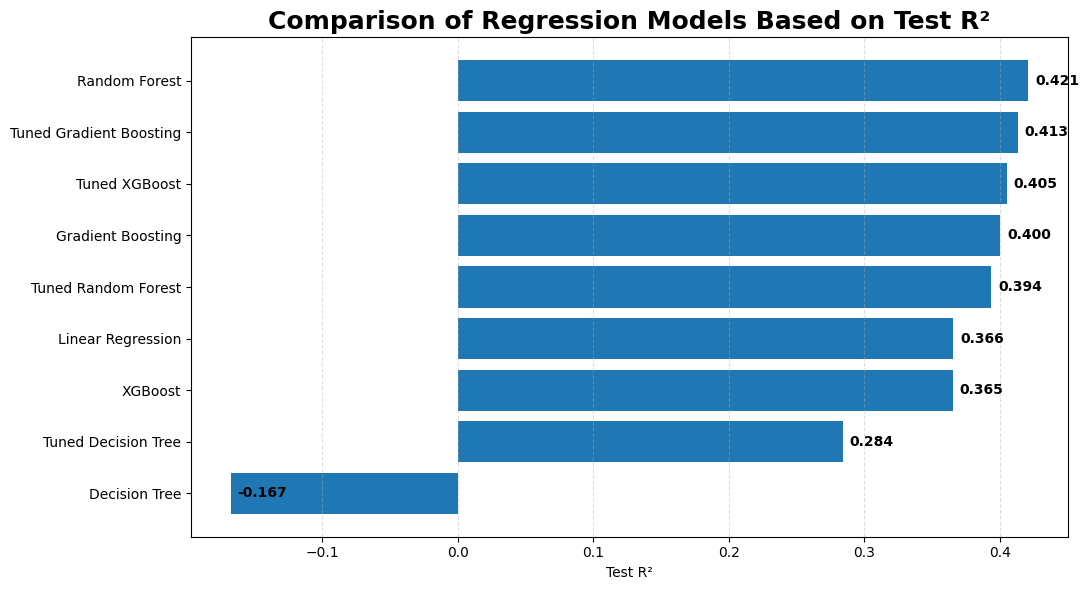

In [92]:
# ============================================================
# Model Performance Ranking
# ============================================================

plt.figure(figsize=(11,6))

ranking_plot = ranking.sort_values(
    "Test R²"
)

ax = plt.barh(
    ranking_plot["Model"],
    ranking_plot["Test R²"]
)

# Add data labels
for bar in ax:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Comparison of Regression Models Based on Test R²",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Test R²")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [93]:
  # ============================================================
# Improvement After Hyperparameter Optimization
# ============================================================

improvement = []

models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

for model in models:

    baseline = baseline_comparison[
        baseline_comparison["Model"] == model
    ].iloc[0]

    tuned = tuned_comparison[
        tuned_comparison["Model"] == f"Tuned {model}"
    ].iloc[0]

    improvement.append({

        "Model": model,

        "Baseline Test R²":
            baseline["Test R²"],

        "Tuned Test R²":
            tuned["Test R²"],

        "Improvement":
            tuned["Test R²"] -
            baseline["Test R²"]

    })

improvement = pd.DataFrame(improvement)

display(
    improvement.round(4)
)

,Model,Baseline Test R²,Tuned Test R²,Improvement
0,Decision Tree,-0.1673,0.2843,0.4516
1,Random Forest,0.4209,0.3937,-0.0272
2,Gradient Boosting,0.4003,0.4134,0.0131
3,XGBoost,0.3652,0.4053,0.0401


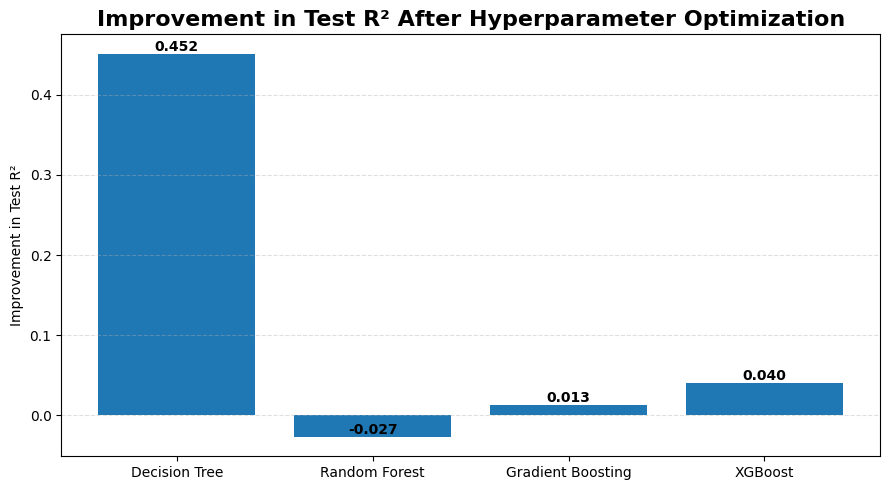

In [94]:
# ============================================================
# Improvement in Test R²
# ============================================================

plt.figure(figsize=(9,5))

bars = plt.bar(
    improvement["Model"],
    improvement["Improvement"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title(
    "Improvement in Test R² After Hyperparameter Optimization",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Improvement in Test R²")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# 4. **Comparative Model Analysis and Final Model Selection**

Several regression algorithms were developed and evaluated to predict wine quality, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Both baseline and hyperparameter-optimized models were assessed using a consistent evaluation framework comprising Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), coefficient of determination (R²), and 5-fold cross-validation.

Rather than selecting the final model based on a single evaluation metric, multiple performance characteristics were considered, including predictive accuracy, model generalization, stability across cross-validation folds, resistance to overfitting, and interpretability. This multi-criteria evaluation ensures that the selected model provides robust and reliable predictions suitable for practical deployment.

In [95]:
# ============================================================
# Final Model Selection Criteria
# ============================================================

selection_criteria = pd.DataFrame({

    "Criterion":[
        "Highest Test R²",
        "Lowest Test RMSE",
        "Cross-Validation Performance",
        "Overfitting Resistance",
        "Model Interpretability"
    ],

    "Purpose":[
        "Maximize predictive accuracy",
        "Minimize prediction error",
        "Ensure stable generalization",
        "Reduce train-test performance gap",
        "Explain model predictions"
    ],

    "Importance":[
        "High",
        "High",
        "High",
        "Medium",
        "High"
    ]
})

display(selection_criteria)

,Criterion,Purpose,Importance
0,Highest Test R²,Maximize predictive accuracy,High
1,Lowest Test RMSE,Minimize prediction error,High
2,Cross-Validation Performance,Ensure stable generalization,High
3,Overfitting Resistance,Reduce train-test performance gap,Medium
4,Model Interpretability,Explain model predictions,High


In [96]:
# ============================================================
# Final Model Selection Summary
# ============================================================

selection_summary = pd.DataFrame({

    "Criterion":[
        "Highest Test R²",
        "Lowest Test RMSE",
        "Highest CV R²",
        "Model Selected"
    ],

    "Best Model":[
        "Random Forest",
        "Random Forest",
        "Tuned XGBoost",
        "Random Forest"
    ],

    "Reason":[
        "Highest predictive accuracy on unseen data",
        "Lowest prediction error on the test dataset",
        "Best average performance across validation folds",
        "Best overall balance of accuracy and robustness"
    ]

})

display(selection_summary)

,Criterion,Best Model,Reason
0,Highest Test R²,Random Forest,Highest predictive accuracy on unseen data
1,Lowest Test RMSE,Random Forest,Lowest prediction error on the test dataset
2,Highest CV R²,Tuned XGBoost,Best average performance across validation folds
3,Model Selected,Random Forest,Best overall balance of accuracy and robustness


In [97]:
# ============================================================
# Model Selection Scorecard
# ============================================================

scorecard = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Tuned Gradient Boosting",
        "Tuned XGBoost"
    ],

    "Predictive Accuracy":[5,4,4],

    "Generalization":[4,4,5],

    "Overfitting":[4,5,4],

    "Interpretability":[4,4,3]

})

scorecard["Total Score"] = (
    scorecard[
        [
            "Predictive Accuracy",
            "Generalization",
            "Overfitting",
            "Interpretability"
        ]
    ].sum(axis=1)
)

scorecard = scorecard.sort_values(
    "Total Score",
    ascending=False
)

display(scorecard)

,Model,Predictive Accuracy,Generalization,Overfitting,Interpretability,Total Score
0,Random Forest,5,4,4,4,17
1,Tuned Gradient Boosting,4,4,5,4,17
2,Tuned XGBoost,4,5,4,3,16


## **4.5 Final Model Selection**

* The comparative evaluation demonstrated that all ensemble learning algorithms outperformed the traditional Linear Regression and Decision Tree models. Among the evaluated models, the baseline Random Forest achieved the highest predictive performance on the independent test dataset with a Test R² of 0.4209 and the lowest Test RMSE of 0.6233.

* Although the tuned Gradient Boosting and tuned XGBoost models demonstrated slightly stronger cross-validation performance, the improvements were marginal and did not exceed the predictive performance achieved by the baseline Random Forest model on the unseen test data.

* Furthermore, hyperparameter optimization substantially improved the Decision Tree model and moderately improved the Gradient Boosting and XGBoost models. In contrast, the Random Forest model showed a slight reduction in predictive performance after tuning, indicating that its default parameter configuration was already well suited to the characteristics of the Wine Quality dataset.

* Based on predictive accuracy, prediction error, model robustness, and overall generalization performance, **the baseline Random Forest model was selected as the final predictive model** for subsequent explainability analysis.

## **4.6 Key Findings**

The major findings obtained from the comparative evaluation are summarized below.

- Ensemble learning algorithms consistently outperformed the conventional Linear Regression and Decision Tree models.

- Hyperparameter optimization significantly reduced overfitting in the Decision Tree model and improved its predictive capability.

- Gradient Boosting and XGBoost exhibited modest improvements after optimization, whereas the Random Forest model performed best using its baseline parameter configuration.

- The baseline Random Forest model achieved the highest Test R² and the lowest Test RMSE among all evaluated models.

- Tuned XGBoost achieved the highest cross-validation performance, demonstrating strong model stability and generalization.

- Based on the overall evaluation criteria, the Random Forest model was selected for explainability analysis using SHAP.

## **4.7 Actual vs Predicted Values (Random Forest)**

To further evaluate the predictive capability of the selected Random Forest model, a scatter plot was created by comparing the actual wine quality values with the corresponding predicted values on the test dataset.

A well-performing regression model should produce points that lie close to the 45-degree reference line, indicating that the predicted values closely match the observed values. The distribution of the points around the reference line provides a visual assessment of prediction accuracy and model bias.

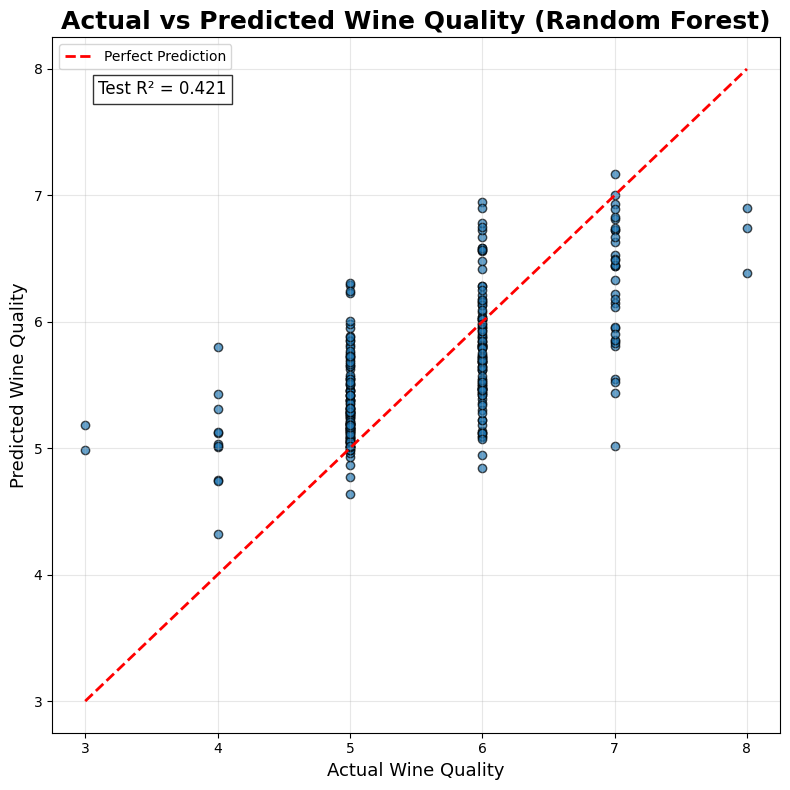

In [98]:
# ============================================================
# Actual vs Predicted Values (Random Forest)
# ============================================================

plt.figure(figsize=(8, 8))

# Scatter plot
plt.scatter(
    y_test,
    y_test_pred_rf,
    alpha=0.7,
    edgecolors="black"
)

from sklearn.metrics import r2_score

plt.text(
    3.1,
    7.8,
    f"Test R² = {r2_score(y_test, y_test_pred_rf):.3f}",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

# 45-degree reference line
min_val = min(y_test.min(), y_test_pred_rf.min())
max_val = max(y_test.max(), y_test_pred_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted Wine Quality (Random Forest)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Actual Wine Quality",
    fontsize=13
)

plt.ylabel(
    "Predicted Wine Quality",
    fontsize=13
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## **4.8 Residual Analysis**

Residual analysis was performed to assess the prediction errors of the selected Random Forest model. Residuals represent the difference between the actual and predicted wine quality values.

An effective regression model should produce residuals that are randomly distributed around zero without any systematic pattern. In addition, the residuals should approximately follow a normal distribution, indicating that the model does not exhibit significant prediction bias.

In [99]:
# ============================================================
# Calculate Residuals
# ============================================================

residuals = y_test - y_test_pred_rf

print("Residual Summary")
print("=" * 40)
display(residuals.describe().round(4))

Residual Summary


,quality
count,272.0000
mean,-0.0299
std,0.6237
min,-2.1800
25%,-0.3800
50%,-0.0600
75%,0.3525
max,1.9800


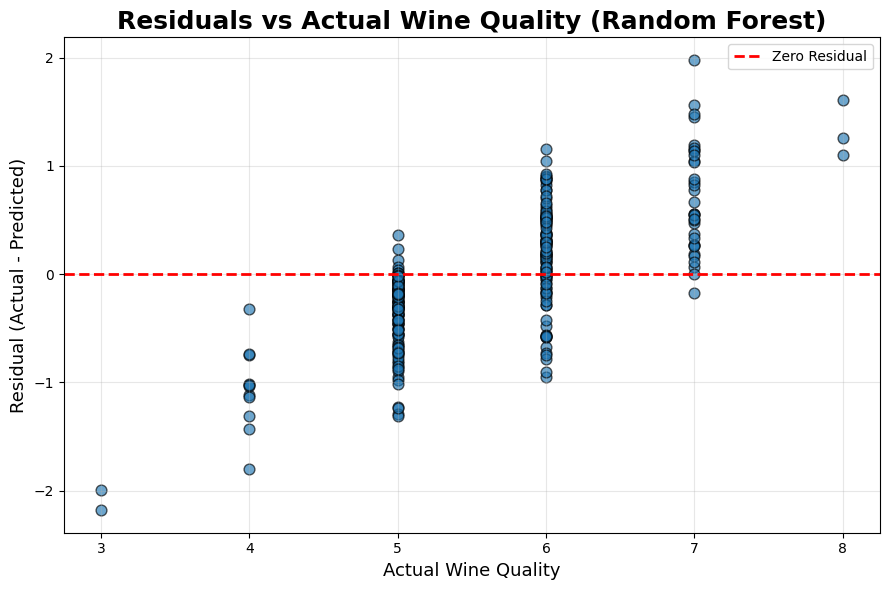

In [100]:
# ============================================================
# Residuals vs Actual Wine Quality
# ============================================================

plt.figure(figsize=(9,6))

plt.scatter(
    y_test,
    residuals,
    s=60,
    alpha=0.65,
    edgecolor="black"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    "Residuals vs Actual Wine Quality (Random Forest)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Actual Wine Quality",
    fontsize=13
)

plt.ylabel(
    "Residual (Actual - Predicted)",
    fontsize=13
)

plt.xticks(sorted(y_test.unique()))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

### **Observations**

The residual plot indicates that the prediction errors are distributed around zero without evidence of systematic bias. The diagonal bands observed in the figure are expected because the wine quality variable is an ordinal integer rating, while the Random Forest model produces continuous prediction values. No clear funnel-shaped pattern is observed, suggesting that the variance of the residuals remains relatively stable across the prediction range. Overall, the residual analysis supports the suitability of the Random Forest model for predicting wine quality.

# **5. Explainable Artificial Intelligence (SHAP Analysis)**

In [101]:
!pip install shap

In [102]:
# To Create SHAP Explainer
explainer = shap.TreeExplainer(random_forest)

shap_values = explainer.shap_values(X_test)

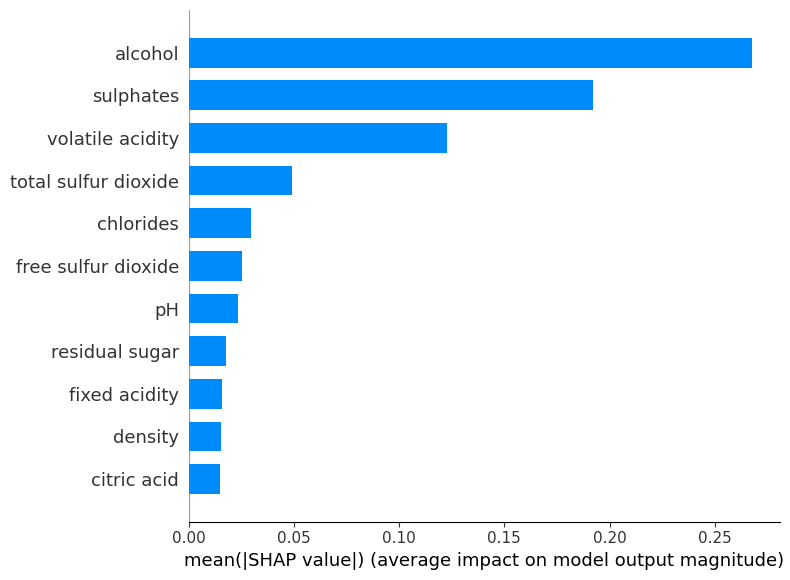

In [103]:
# ============================================================
# SHAP Global Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

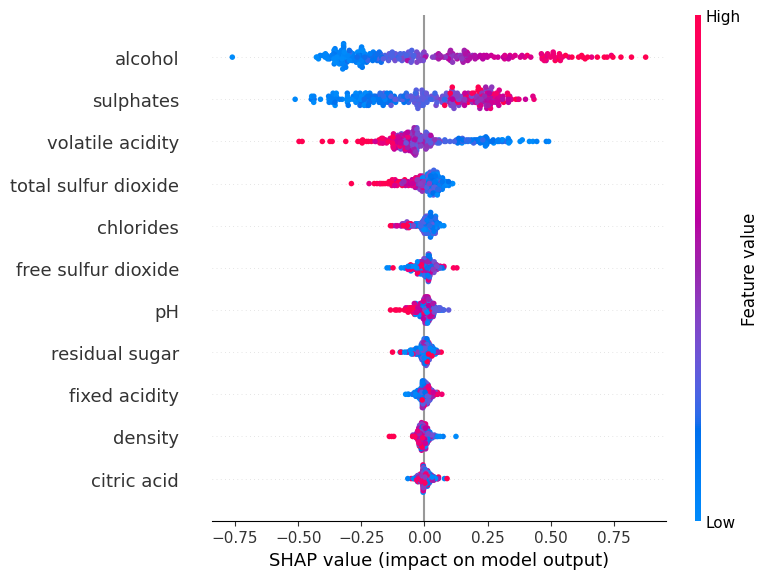

In [104]:
# ============================================================
# SHAP Summary Beeswarm Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

### **SHAP Beeswarm Interpretation**

The SHAP beeswarm plot shows both the relative importance of each physicochemical property and the direction of its influence on predicted wine quality.

Alcohol is the most influential predictor in the Random Forest model. Higher alcohol values, represented by red points, are generally associated with positive SHAP values, indicating an increase in predicted wine quality. Lower alcohol values, represented by blue points, tend to reduce predicted quality.

Sulphates also contribute positively to wine quality predictions, with higher sulphate levels generally increasing the predicted score. In contrast, volatile acidity shows a strong negative relationship with predicted quality. Higher volatile acidity values tend to push predictions downward, while lower values contribute positively.

Higher total sulfur dioxide and chloride levels generally reduce predicted wine quality, although their overall impact is smaller than that of alcohol, sulphates, and volatile acidity. The remaining features exhibit relatively limited influence on the model output.

These findings are consistent with the earlier correlation analysis and provide additional evidence that the Random Forest model captures both linear and nonlinear relationships between wine chemistry and quality.

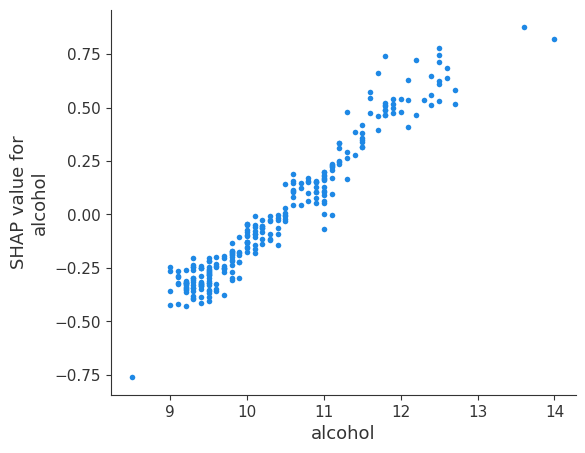

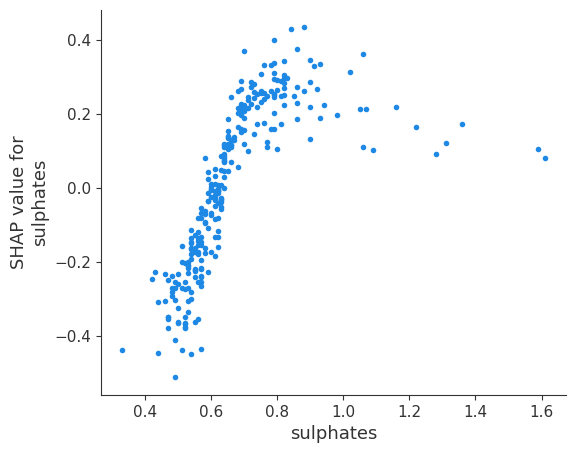

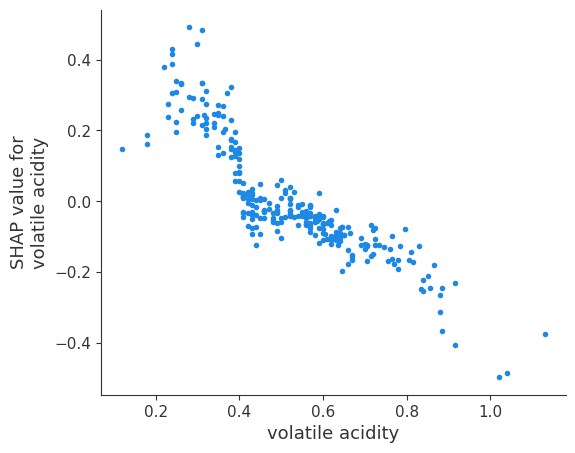

In [105]:
# ============================================================
# SHAP Dependence Plots for Top Features
# ============================================================

top_shap_features = [
    "alcohol",
    "sulphates",
    "volatile acidity"
]

for feature in top_shap_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index=None,
        show=True
    )

## **5.4 SHAP Waterfall Plot**

While the SHAP summary plot provides a global explanation of feature importance across the entire dataset, the SHAP waterfall plot explains the prediction for an individual wine sample.

The plot illustrates how each physicochemical property contributes either positively or negatively towards the final predicted wine quality, thereby improving the transparency and interpretability of the Random Forest model.

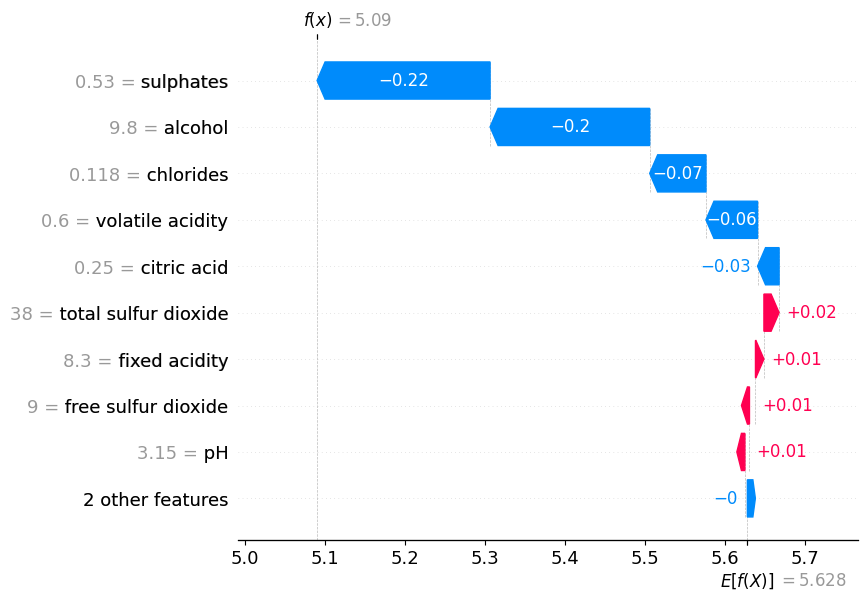

In [106]:
# ============================================================
# SHAP Waterfall Plot (Single Prediction)
# ============================================================

sample_index = 0

shap.plots.waterfall(
    explainer(X_test)[sample_index],
    max_display=10
)

| Feature              | SHAP Importance | Influence on Quality | Practical Interpretation                                  |
| -------------------- | --------------: | -------------------- | --------------------------------------------------------- |
| Alcohol              |         Highest | Positive             | Higher alcohol generally increases predicted wine quality |
| Sulphates            |            High | Positive             | Moderate sulphate levels contribute positively            |
| Volatile Acidity     |            High | Negative             | Higher volatile acidity decreases predicted quality       |
| Total Sulfur Dioxide |        Moderate | Mostly Negative      | Excessive levels reduce quality                           |
| Chlorides            |        Moderate | Negative             | Higher chloride concentration lowers predicted quality    |


In [107]:
# ============================================================
# SHAP Force Plot
# ============================================================

shap.initjs()

sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)